In [1842]:
from datetime import datetime, timedelta
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np

In [1843]:
#IMPORT FILE
nmdb = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/NMDB_IRK3_YKTK_TXBY_may_2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER
cols = ['YMD', 'HMS', 'IRK3', 'YKTK', 'TXBY']
nmdb_df = pd.read_csv(nmdb, sep=r"\s+",skiprows=27,names=cols)

nmdb_df

,YMD,HMS,IRK3,YKTK,TXBY
0,2024-05-06,00:00:00,407.0,201.800,94.600
1,2024-05-06,00:02:00,407.0,204.067,93.867
2,2024-05-06,00:04:00,405.5,202.067,93.267
3,2024-05-06,00:06:00,405.5,202.333,96.933
4,2024-05-06,00:08:00,406.0,201.000,93.400
...,...,...,...,...,...
12235,2024-05-22,23:50:00,384.0,197.667,92.667
12236,2024-05-22,23:52:00,391.0,197.933,90.667
12237,2024-05-22,23:54:00,389.0,195.600,91.133
12238,2024-05-22,23:56:00,389.0,194.467,92.667


In [1844]:
# NEW 'UT' COLUMN
nmdb_df['UT'] = pd.date_range( start='2024-05-06 00:00:00', periods=len(nmdb_df), freq='2min')

nmdb_df

,YMD,HMS,IRK3,YKTK,TXBY,UT
0,2024-05-06,00:00:00,407.0,201.800,94.600,2024-05-06 00:00:00
1,2024-05-06,00:02:00,407.0,204.067,93.867,2024-05-06 00:02:00
2,2024-05-06,00:04:00,405.5,202.067,93.267,2024-05-06 00:04:00
3,2024-05-06,00:06:00,405.5,202.333,96.933,2024-05-06 00:06:00
4,2024-05-06,00:08:00,406.0,201.000,93.400,2024-05-06 00:08:00
...,...,...,...,...,...,...
12235,2024-05-22,23:50:00,384.0,197.667,92.667,2024-05-22 23:50:00
12236,2024-05-22,23:52:00,391.0,197.933,90.667,2024-05-22 23:52:00
12237,2024-05-22,23:54:00,389.0,195.600,91.133,2024-05-22 23:54:00
12238,2024-05-22,23:56:00,389.0,194.467,92.667,2024-05-22 23:56:00


In [1845]:
# REPLACE NULL WITH NAN
nmdb_df = nmdb_df.replace(['null'], np.nan)

nmdb_df

,YMD,HMS,IRK3,YKTK,TXBY,UT
0,2024-05-06,00:00:00,407.0,201.800,94.600,2024-05-06 00:00:00
1,2024-05-06,00:02:00,407.0,204.067,93.867,2024-05-06 00:02:00
2,2024-05-06,00:04:00,405.5,202.067,93.267,2024-05-06 00:04:00
3,2024-05-06,00:06:00,405.5,202.333,96.933,2024-05-06 00:06:00
4,2024-05-06,00:08:00,406.0,201.000,93.400,2024-05-06 00:08:00
...,...,...,...,...,...,...
12235,2024-05-22,23:50:00,384.0,197.667,92.667,2024-05-22 23:50:00
12236,2024-05-22,23:52:00,391.0,197.933,90.667,2024-05-22 23:52:00
12237,2024-05-22,23:54:00,389.0,195.600,91.133,2024-05-22 23:54:00
12238,2024-05-22,23:56:00,389.0,194.467,92.667,2024-05-22 23:56:00


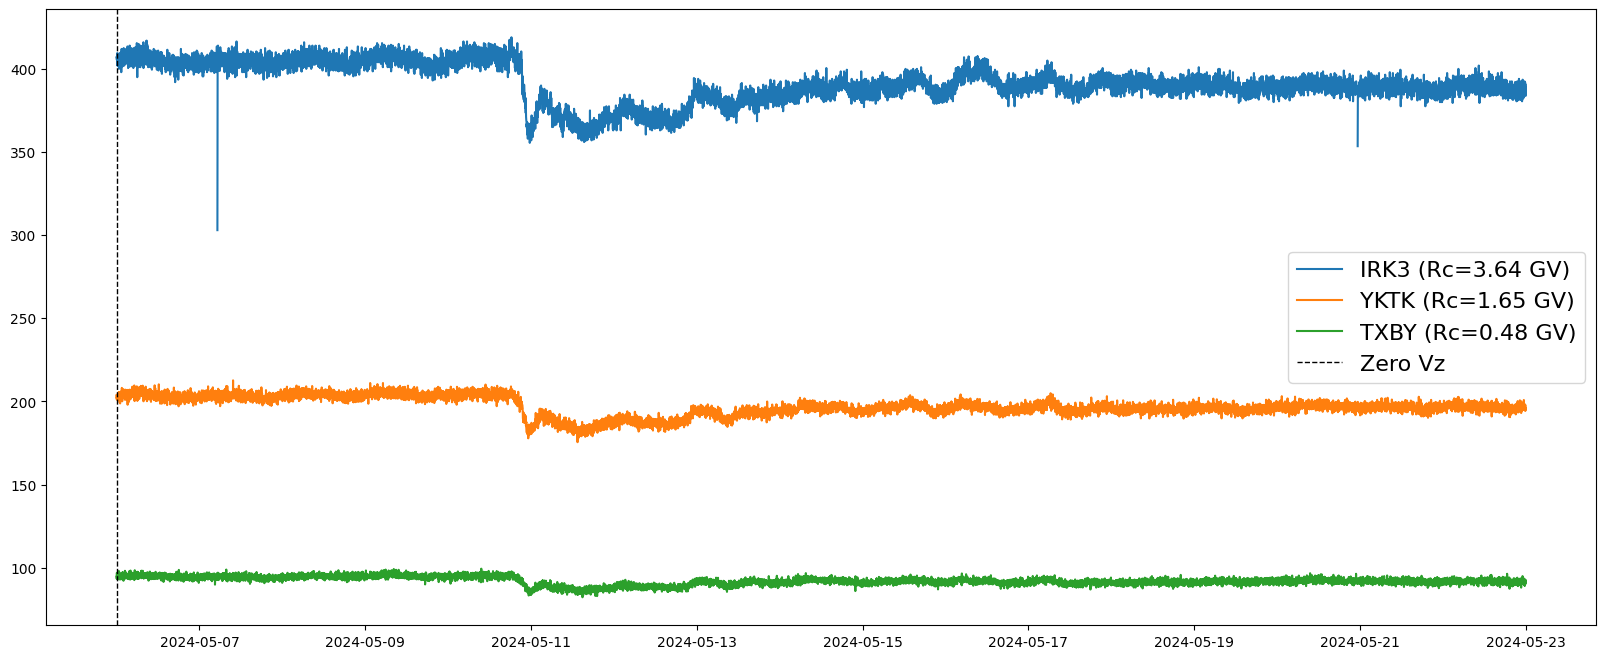

In [1846]:
fig = plt.figure(1, figsize = (20,8))
plt.plot(nmdb_df['UT'].to_numpy(), nmdb_df['IRK3'].to_numpy(), label='IRK3 (Rc=3.64 GV)')
plt.plot(nmdb_df['UT'].to_numpy(), nmdb_df['YKTK'].to_numpy(), label='YKTK (Rc=1.65 GV)')
plt.plot(nmdb_df['UT'].to_numpy(), nmdb_df['TXBY'].to_numpy(), label='TXBY (Rc=0.48 GV)')
plt.axvline(x=pd.to_datetime('2024-05-06 00:00:00'), color='black', linestyle='--', linewidth=1, label='Zero Vz') # Horizontal linebase

#plt.ylim(0, 250)
plt.legend(fontsize=16)
plt.show()

In [1847]:
IRK3_mean_quiet = nmdb_df[nmdb_df['UT'] < pd.to_datetime('2024-05-10 12:00:00')]['IRK3'].mean()
YKTK_mean_quiet = nmdb_df[nmdb_df['UT'] < pd.to_datetime('2024-05-10 12:00:00')]['YKTK'].mean()
TXBY_mean_quiet = nmdb_df[nmdb_df['UT'] < pd.to_datetime('2024-05-10 12:00:00')]['TXBY'].mean()

print(f"El promedio de IRK3 antes de {pd.to_datetime('2024-05-10 12:00:00')} es: {IRK3_mean_quiet:.3f}")
print(f"El promedio de YKTK antes de {pd.to_datetime('2024-05-10 12:00:00')} es: {YKTK_mean_quiet:.3f}")
print(f"El promedio de TXBY antes de {pd.to_datetime('2024-05-10 12:00:00')} es: {TXBY_mean_quiet:.3f}")

El promedio de IRK3 antes de 2024-05-10 12:00:00 es: 405.110
El promedio de YKTK antes de 2024-05-10 12:00:00 es: 203.700
El promedio de TXBY antes de 2024-05-10 12:00:00 es: 94.776


In [1848]:
# CREATE A COPY
nmdb_df_quiet = nmdb_df.copy()

# CONVERT TO NUMERIC AND SUBSTRACT THE MEANS
nmdb_df_quiet['IRK3'] = (pd.to_numeric(nmdb_df['IRK3'], errors='coerce') - IRK3_mean_quiet)*100/IRK3_mean_quiet

nmdb_df_quiet['YKTK'] = (pd.to_numeric(nmdb_df['YKTK'], errors='coerce') - YKTK_mean_quiet)*100/YKTK_mean_quiet

nmdb_df_quiet['TXBY'] = (pd.to_numeric(nmdb_df['TXBY'], errors='coerce') - TXBY_mean_quiet)*100/TXBY_mean_quiet

nmdb_df_quiet

,YMD,HMS,IRK3,YKTK,TXBY,UT
0,2024-05-06,00:00:00,0.466550,-0.932796,-0.185425,2024-05-06 00:00:00
1,2024-05-06,00:02:00,0.466550,0.180115,-0.958830,2024-05-06 00:02:00
2,2024-05-06,00:04:00,0.096280,-0.801721,-1.591903,2024-05-06 00:04:00
3,2024-05-06,00:06:00,0.096280,-0.671137,2.276175,2024-05-06 00:06:00
4,2024-05-06,00:08:00,0.219703,-1.325530,-1.451572,2024-05-06 00:08:00
...,...,...,...,...,...,...
12235,2024-05-22,23:50:00,-5.210921,-2.961759,-2.224977,2024-05-22 23:50:00
12236,2024-05-22,23:52:00,-3.482995,-2.831175,-4.335222,2024-05-22 23:52:00
12237,2024-05-22,23:54:00,-3.976688,-3.976486,-3.843535,2024-05-22 23:54:00
12238,2024-05-22,23:56:00,-3.976688,-4.532696,-2.224977,2024-05-22 23:56:00


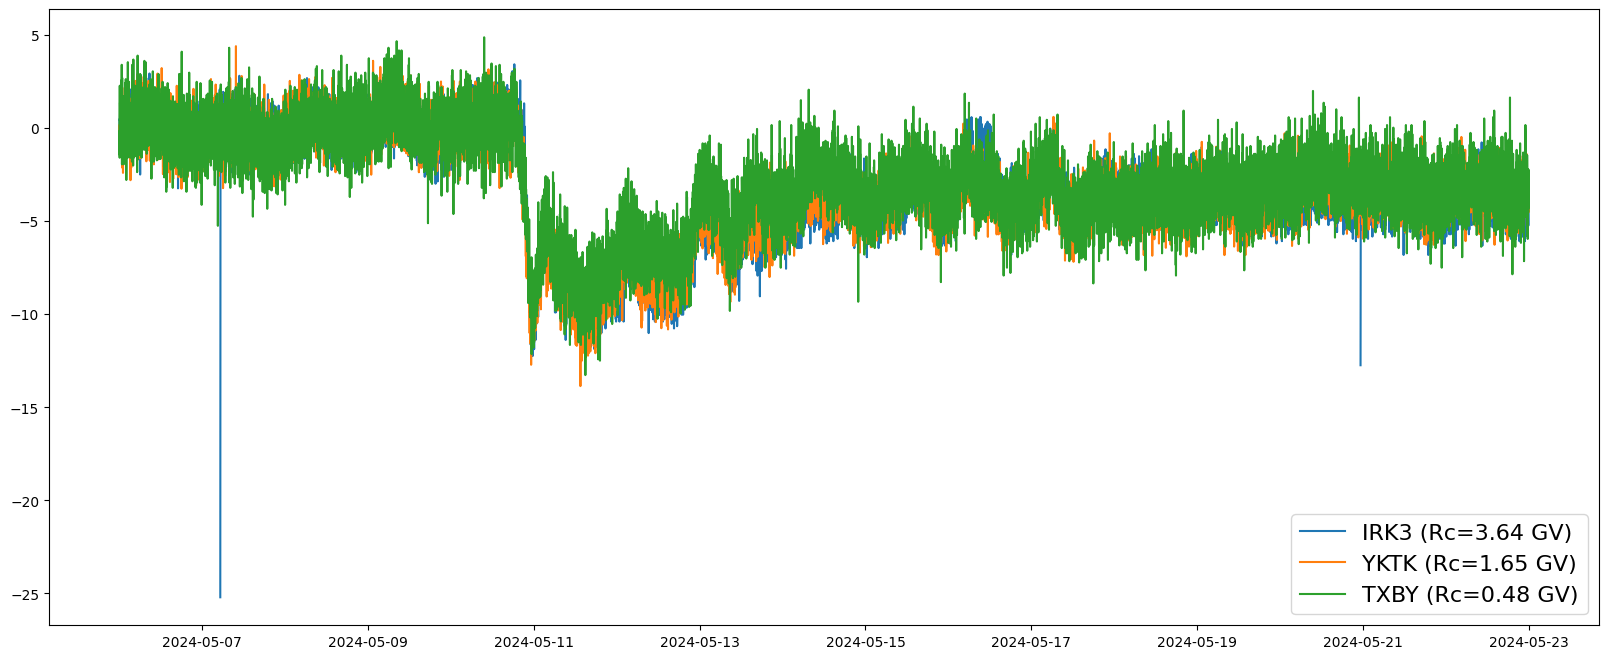

In [1849]:
fig = plt.figure(1, figsize = (20,8))
plt.plot(nmdb_df_quiet['UT'].to_numpy(), nmdb_df_quiet['IRK3'].to_numpy(), label='IRK3 (Rc=3.64 GV)')
plt.plot(nmdb_df_quiet['UT'].to_numpy(), nmdb_df_quiet['YKTK'].to_numpy(), label='YKTK (Rc=1.65 GV)')
plt.plot(nmdb_df_quiet['UT'].to_numpy(), nmdb_df_quiet['TXBY'].to_numpy(), label='TXBY (Rc=0.48 GV)')

plt.legend(fontsize=16)
plt.show()

### ROLLING PARA MUESTREAR LOS DATOS A 10 MINUTOS

In [1850]:
window = 30

nmdb_df_quiet_smooth = nmdb_df_quiet.copy()

nmdb_df_quiet_smooth['IRK3_smooth'] = (
    nmdb_df_quiet_smooth['IRK3']
    .rolling(window=window, center=True)
    .mean()
)

nmdb_df_quiet_smooth['YKTK_smooth'] = (
    nmdb_df_quiet_smooth['YKTK']
    .rolling(window=window, center=True)
    .mean()
)

nmdb_df_quiet_smooth['TXBY_smooth'] = (
    nmdb_df_quiet_smooth['TXBY']
    .rolling(window=window, center=True)
    .mean()
)

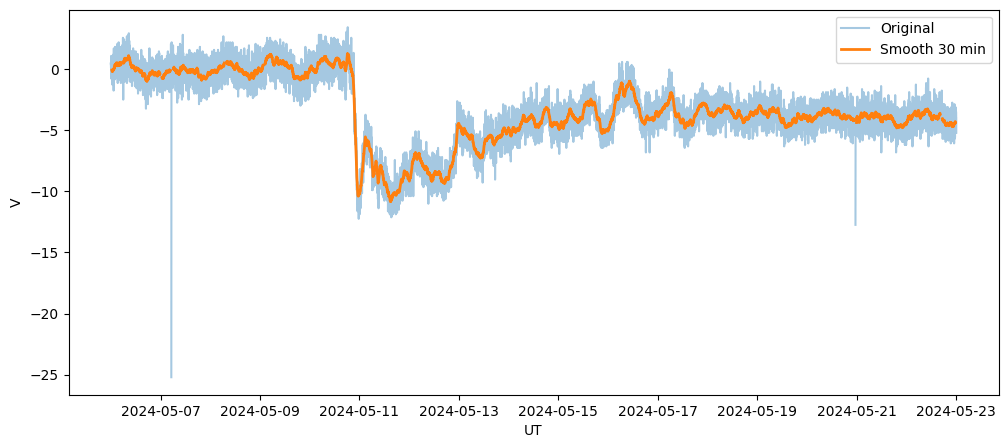

In [1851]:
plt.figure(figsize=(12,5))

plt.plot(nmdb_df_quiet_smooth['UT'], nmdb_df_quiet_smooth['IRK3'],
         alpha=0.4, label='Original')

plt.plot(nmdb_df_quiet_smooth['UT'], nmdb_df_quiet_smooth['IRK3_smooth'],
         linewidth=2, label='Smooth 30 min')

plt.legend()
plt.xlabel('UT')
plt.ylabel('V')
plt.show()

### INDICE DST

In [1852]:
#IMPORT FILE
dst = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/DST_kyotodata_may2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER
cols = ['Day']

for i in range(1,25):
    cols.append(i)

raw_dst_df = pd.read_csv(dst, sep=r"\s+",skiprows=7,names=cols)

raw_dst_df

,Day,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,6,-33,-43,-35,-34,-33,-27,-17,-17,-9,...,-3,1,-4,-9,-12,-13,-13,-10,-8,-5
1,7,-6,-6,-4,-7,-7,-3,2,6,4,...,-8,-8,-10,-15,-12,-8,-2,1,5,4
2,8,3,5,7,5,6,9,9,9,8,...,6,5,5,3,3,5,7,11,15,14
3,9,15,17,18,15,15,14,14,13,14,...,21,18,18,20,22,22,21,20,20,17
4,10,12,10,12,21,16,7,9,16,13,...,10,23,25,66,-33,-131,-157,-277,-339,-308
5,11,-313,-390,-406,-395,-389,-358,-320,-374,-364,...,-281,-265,-270,-248,-203,-198,-190,-169,-157,-167
6,12,-150,-142,-135,-138,-138,-143,-132,-132,-131,...,-102,-96,-97,-93,-87,-82,-75,-77,-86,-81
7,13,-74,-76,-83,-88,-93,-86,-84,-67,-63,...,-57,-51,-54,-55,-55,-51,-48,-44,-43,-46
8,14,-45,-48,-49,-51,-46,-42,-41,-43,-46,...,-45,-44,-42,-42,-45,-44,-41,-39,-38,-41
9,15,-42,-40,-39,-39,-32,-30,-33,-35,-33,...,-41,-40,-40,-38,-32,-32,-36,-42,-44,-49


In [1853]:
dst_df = pd.DataFrame()

dst_df['UT'] = pd.date_range(
        start=pd.to_datetime('2024-05-06 01:00:00'), 
        periods=24*len(raw_dst_df), 
        freq='h'
    )

dst_values = []

for i in range(len(raw_dst_df)):

    for hour in range(1, 25):

        dst_values.append(
            raw_dst_df.iloc[i][hour]
        )

dst_df['Dst'] = dst_values

dst_df

,UT,Dst
0,2024-05-06 01:00:00,-33
1,2024-05-06 02:00:00,-43
2,2024-05-06 03:00:00,-35
3,2024-05-06 04:00:00,-34
4,2024-05-06 05:00:00,-33
...,...,...
403,2024-05-22 20:00:00,6
404,2024-05-22 21:00:00,8
405,2024-05-22 22:00:00,8
406,2024-05-22 23:00:00,9


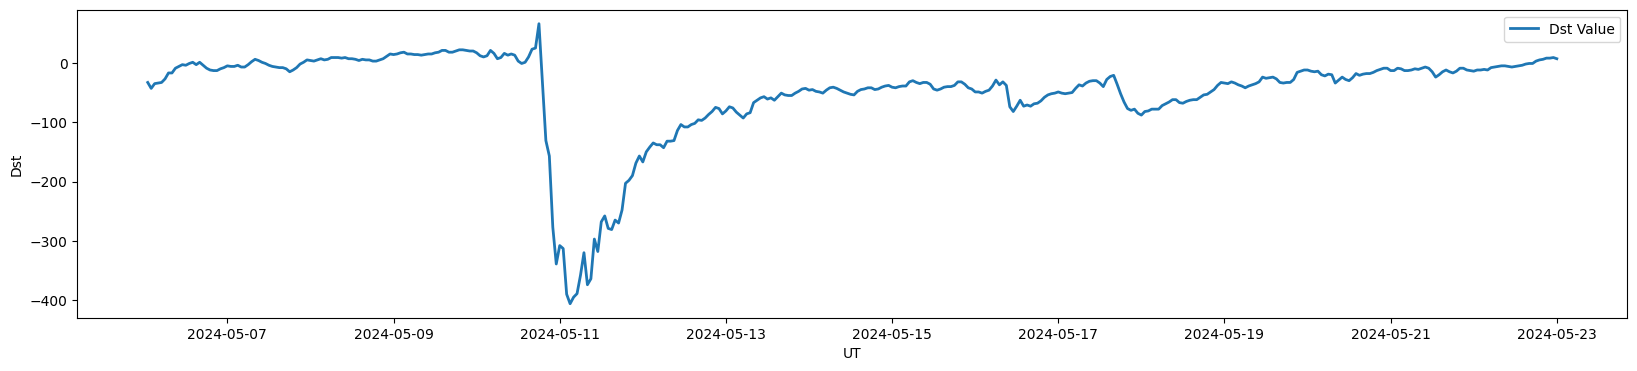

In [1854]:
plt.figure(figsize=(20,4))

plt.plot(dst_df['UT'], dst_df['Dst'], linewidth=2, label='Dst Value')

plt.legend()
plt.xlabel('UT')
plt.ylabel('Dst')
plt.show()

### INDICE Kp

In [1855]:
#IMPORT FILE
kpindex = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/GFZcenter_Kp_ap_may_2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER
cols = ['YYYY', 'MM', 'DD', 'HH', 'HH_m', 'days', 'days_m', 'kp', 'ap', 'D']                               
kp_df = pd.read_csv(kpindex, sep=r"\s+",skiprows=1,names=cols)

kp_df

,YYYY,MM,DD,HH,HH_m,days,days_m,kp,ap,D
0,2024,5,6,3.0,4.5,33729.125,33729.1875,2.333,9,1
1,2024,5,6,6.0,7.5,33729.250,33729.3125,2.333,9,1
2,2024,5,6,9.0,10.5,33729.375,33729.4375,2.333,9,1
3,2024,5,6,12.0,13.5,33729.500,33729.5625,4.000,27,1
4,2024,5,6,15.0,16.5,33729.625,33729.6875,2.000,7,1
...,...,...,...,...,...,...,...,...,...,...
130,2024,5,22,9.0,10.5,33745.375,33745.4375,0.000,0,1
131,2024,5,22,12.0,13.5,33745.500,33745.5625,0.333,2,1
132,2024,5,22,15.0,16.5,33745.625,33745.6875,0.667,3,1
133,2024,5,22,18.0,19.5,33745.750,33745.8125,1.333,5,1


In [1856]:
kp_df['UT'] = pd.to_datetime({
    'year':  kp_df['YYYY'].astype(int),
    'month': kp_df['MM'].astype(int),
    'day':   kp_df['DD'].astype(int),
    'hour':  kp_df['HH'].astype(int)
})

kp_df

,YYYY,MM,DD,HH,HH_m,days,days_m,kp,ap,D,UT
0,2024,5,6,3.0,4.5,33729.125,33729.1875,2.333,9,1,2024-05-06 03:00:00
1,2024,5,6,6.0,7.5,33729.250,33729.3125,2.333,9,1,2024-05-06 06:00:00
2,2024,5,6,9.0,10.5,33729.375,33729.4375,2.333,9,1,2024-05-06 09:00:00
3,2024,5,6,12.0,13.5,33729.500,33729.5625,4.000,27,1,2024-05-06 12:00:00
4,2024,5,6,15.0,16.5,33729.625,33729.6875,2.000,7,1,2024-05-06 15:00:00
...,...,...,...,...,...,...,...,...,...,...,...
130,2024,5,22,9.0,10.5,33745.375,33745.4375,0.000,0,1,2024-05-22 09:00:00
131,2024,5,22,12.0,13.5,33745.500,33745.5625,0.333,2,1,2024-05-22 12:00:00
132,2024,5,22,15.0,16.5,33745.625,33745.6875,0.667,3,1,2024-05-22 15:00:00
133,2024,5,22,18.0,19.5,33745.750,33745.8125,1.333,5,1,2024-05-22 18:00:00


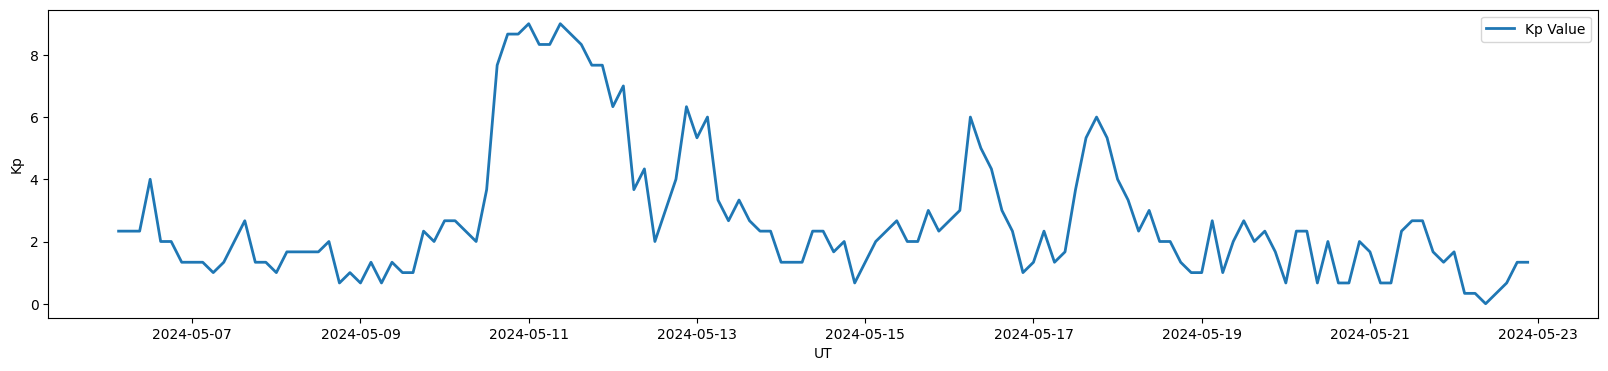

In [1857]:
plt.figure(figsize=(20,4))

plt.plot(kp_df['UT'], kp_df['kp'], linewidth=2, label='Kp Value')

plt.legend()
plt.xlabel('UT')
plt.ylabel('Kp')
plt.show()

### OMNIWeb: B_total, Bz, V_sw, densidad, SYM/H

In [1858]:
#IMPORT FILE
omni = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/Omniweb_BT_BZ_Vsw_densidad_SYMH_may2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER
cols = ['YYYY', 'DOY', 'HR', 'MN', 'B_total', 'IMF_Bz', 'V_sw', 'densidad', 'SYM_H']                                          
omni_df = pd.read_csv(omni, sep=r"\s+",skiprows=8,names=cols)

omni_df

,YYYY,DOY,HR,MN,B_total,IMF_Bz,V_sw,densidad,SYM_H
0,2024,127,0,0,12.01,-9.68,367.2,23.56,-41
1,2024,127,0,1,12.70,-8.55,364.2,30.89,-43
2,2024,127,0,2,12.77,-11.49,364.2,30.89,-44
3,2024,127,0,3,13.19,-10.17,366.6,29.12,-44
4,2024,127,0,4,12.39,-8.34,373.0,24.47,-42
...,...,...,...,...,...,...,...,...,...
24475,2024,143,23,55,5.32,4.35,386.6,7.52,-5
24476,2024,143,23,56,4.95,3.36,388.6,7.56,-5
24477,2024,143,23,57,4.61,2.73,382.5,7.76,-5
24478,2024,143,23,58,4.49,0.67,367.8,8.62,-5


In [1859]:
# REPLACE NULL WITH NAN
omni_df = omni_df.replace(99999.9, np.nan)
omni_df = omni_df.replace(999.99, np.nan)
omni_df = omni_df.replace(9999.99, np.nan)

omni_df

,YYYY,DOY,HR,MN,B_total,IMF_Bz,V_sw,densidad,SYM_H
0,2024,127,0,0,12.01,-9.68,367.2,23.56,-41
1,2024,127,0,1,12.70,-8.55,364.2,30.89,-43
2,2024,127,0,2,12.77,-11.49,364.2,30.89,-44
3,2024,127,0,3,13.19,-10.17,366.6,29.12,-44
4,2024,127,0,4,12.39,-8.34,373.0,24.47,-42
...,...,...,...,...,...,...,...,...,...
24475,2024,143,23,55,5.32,4.35,386.6,7.52,-5
24476,2024,143,23,56,4.95,3.36,388.6,7.56,-5
24477,2024,143,23,57,4.61,2.73,382.5,7.76,-5
24478,2024,143,23,58,4.49,0.67,367.8,8.62,-5


In [1860]:
omni_df['UT'] = (
    pd.to_datetime(omni_df['YYYY'], format='%Y')
    + pd.to_timedelta(omni_df['DOY'] - 1, unit='D')
    + pd.to_timedelta(omni_df['HR'], unit='h')
    + pd.to_timedelta(omni_df['MN'], unit='m')
)

omni_df

,YYYY,DOY,HR,MN,B_total,IMF_Bz,V_sw,densidad,SYM_H,UT
0,2024,127,0,0,12.01,-9.68,367.2,23.56,-41,2024-05-06 00:00:00
1,2024,127,0,1,12.70,-8.55,364.2,30.89,-43,2024-05-06 00:01:00
2,2024,127,0,2,12.77,-11.49,364.2,30.89,-44,2024-05-06 00:02:00
3,2024,127,0,3,13.19,-10.17,366.6,29.12,-44,2024-05-06 00:03:00
4,2024,127,0,4,12.39,-8.34,373.0,24.47,-42,2024-05-06 00:04:00
...,...,...,...,...,...,...,...,...,...,...
24475,2024,143,23,55,5.32,4.35,386.6,7.52,-5,2024-05-22 23:55:00
24476,2024,143,23,56,4.95,3.36,388.6,7.56,-5,2024-05-22 23:56:00
24477,2024,143,23,57,4.61,2.73,382.5,7.76,-5,2024-05-22 23:57:00
24478,2024,143,23,58,4.49,0.67,367.8,8.62,-5,2024-05-22 23:58:00


### DATOS DE MUONES 

In [1861]:
muons = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/Nagoya_Muons_May_2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER
cols = ['year', 'month', 'day', 'hour', 'Vraw', 'N', 'S', 'E', 'W', 'NE', 'NW', 'SE', 'SW', 'N2', 'S2', 'E2', 'W2', 'N3', 'S3', 'E3', 'W3', 'Pres']                                          
muons_df = pd.read_csv(muons, sep=r"\s+",names=cols)#,skiprows=7

muons_df

,year,month,day,hour,Vraw,N,S,E,W,NE,...,SW,N2,S2,E2,W2,N3,S3,E3,W3,Pres
0,2024,5,6,0,2874619,1302328,1288483,1263321,1310225,616374,...,629483,624529,616767,601006,630766,182663,181806,177537,182447,1009.930
1,2024,5,6,1,2874351,1303199,1287816,1262734,1312871,616147,...,629510,625731,615116,600589,631308,182579,180690,178585,182876,1009.719
2,2024,5,6,2,2883126,1304560,1288103,1262630,1312154,617492,...,629811,625626,618525,601873,632009,183162,182368,177766,183735,1010.010
3,2024,5,6,3,2884862,1309433,1292645,1264777,1312098,617605,...,631466,625640,618107,599926,631321,182419,181252,178192,182164,1010.258
4,2024,5,6,4,2891259,1308719,1291127,1267457,1317883,616467,...,633511,625093,618266,601576,632422,183129,182665,178429,183191,1009.536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2024,5,22,19,2840667,1286962,1270217,1246772,1295505,609307,...,623711,620400,610274,594843,625944,181425,180991,176068,182024,1005.966
404,2024,5,22,20,2843496,1288355,1269579,1248105,1297143,611313,...,623191,620864,609545,595620,626312,181770,180290,176732,181263,1006.072
405,2024,5,22,21,2846510,1289258,1274558,1249281,1294957,611300,...,622402,619881,609434,594610,625562,181580,179683,176608,181180,1006.048
406,2024,5,22,22,2845960,1291112,1273176,1249522,1296158,610387,...,623952,620770,609334,595802,625007,180811,179949,176695,181531,1005.762


In [1862]:
muons_df['UT'] = pd.to_datetime({
    'year':  muons_df['year'].astype(int),
    'month': muons_df['month'].astype(int),
    'day':   muons_df['day'].astype(int),
    'hour':  muons_df['hour'].astype(int)
})

muons_df

,year,month,day,hour,Vraw,N,S,E,W,NE,...,N2,S2,E2,W2,N3,S3,E3,W3,Pres,UT
0,2024,5,6,0,2874619,1302328,1288483,1263321,1310225,616374,...,624529,616767,601006,630766,182663,181806,177537,182447,1009.930,2024-05-06 00:00:00
1,2024,5,6,1,2874351,1303199,1287816,1262734,1312871,616147,...,625731,615116,600589,631308,182579,180690,178585,182876,1009.719,2024-05-06 01:00:00
2,2024,5,6,2,2883126,1304560,1288103,1262630,1312154,617492,...,625626,618525,601873,632009,183162,182368,177766,183735,1010.010,2024-05-06 02:00:00
3,2024,5,6,3,2884862,1309433,1292645,1264777,1312098,617605,...,625640,618107,599926,631321,182419,181252,178192,182164,1010.258,2024-05-06 03:00:00
4,2024,5,6,4,2891259,1308719,1291127,1267457,1317883,616467,...,625093,618266,601576,632422,183129,182665,178429,183191,1009.536,2024-05-06 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2024,5,22,19,2840667,1286962,1270217,1246772,1295505,609307,...,620400,610274,594843,625944,181425,180991,176068,182024,1005.966,2024-05-22 19:00:00
404,2024,5,22,20,2843496,1288355,1269579,1248105,1297143,611313,...,620864,609545,595620,626312,181770,180290,176732,181263,1006.072,2024-05-22 20:00:00
405,2024,5,22,21,2846510,1289258,1274558,1249281,1294957,611300,...,619881,609434,594610,625562,181580,179683,176608,181180,1006.048,2024-05-22 21:00:00
406,2024,5,22,22,2845960,1291112,1273176,1249522,1296158,610387,...,620770,609334,595802,625007,180811,179949,176695,181531,1005.762,2024-05-22 22:00:00


In [1863]:
V_mean_quiet = muons_df[muons_df['UT'] < pd.to_datetime('2024-05-10 12:00:00')]['Vraw'].mean()

print(f"El promedio de V antes de {pd.to_datetime('2024-05-10 12:00:00')} es: {V_mean_quiet:.3f}")

El promedio de V antes de 2024-05-10 12:00:00 es: 2892127.157


In [1864]:
# CREATE A COPY
#nmdb_df_quiet = nmdb_df.copy()

# CONVERT TO NUMERIC AND SUBSTRACT THE MEANS
muons_df['V'] = (pd.to_numeric(muons_df['Vraw'], errors='coerce') - V_mean_quiet)*100/V_mean_quiet

muons_df

,year,month,day,hour,Vraw,N,S,E,W,NE,...,S2,E2,W2,N3,S3,E3,W3,Pres,UT,V
0,2024,5,6,0,2874619,1302328,1288483,1263321,1310225,616374,...,616767,601006,630766,182663,181806,177537,182447,1009.930,2024-05-06 00:00:00,-0.605373
1,2024,5,6,1,2874351,1303199,1287816,1262734,1312871,616147,...,615116,600589,631308,182579,180690,178585,182876,1009.719,2024-05-06 01:00:00,-0.614640
2,2024,5,6,2,2883126,1304560,1288103,1262630,1312154,617492,...,618525,601873,632009,183162,182368,177766,183735,1010.010,2024-05-06 02:00:00,-0.311230
3,2024,5,6,3,2884862,1309433,1292645,1264777,1312098,617605,...,618107,599926,631321,182419,181252,178192,182164,1010.258,2024-05-06 03:00:00,-0.251205
4,2024,5,6,4,2891259,1308719,1291127,1267457,1317883,616467,...,618266,601576,632422,183129,182665,178429,183191,1009.536,2024-05-06 04:00:00,-0.030018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2024,5,22,19,2840667,1286962,1270217,1246772,1295505,609307,...,610274,594843,625944,181425,180991,176068,182024,1005.966,2024-05-22 19:00:00,-1.779319
404,2024,5,22,20,2843496,1288355,1269579,1248105,1297143,611313,...,609545,595620,626312,181770,180290,176732,181263,1006.072,2024-05-22 20:00:00,-1.681501
405,2024,5,22,21,2846510,1289258,1274558,1249281,1294957,611300,...,609434,594610,625562,181580,179683,176608,181180,1006.048,2024-05-22 21:00:00,-1.577287
406,2024,5,22,22,2845960,1291112,1273176,1249522,1296158,610387,...,609334,595802,625007,180811,179949,176695,181531,1005.762,2024-05-22 22:00:00,-1.596305


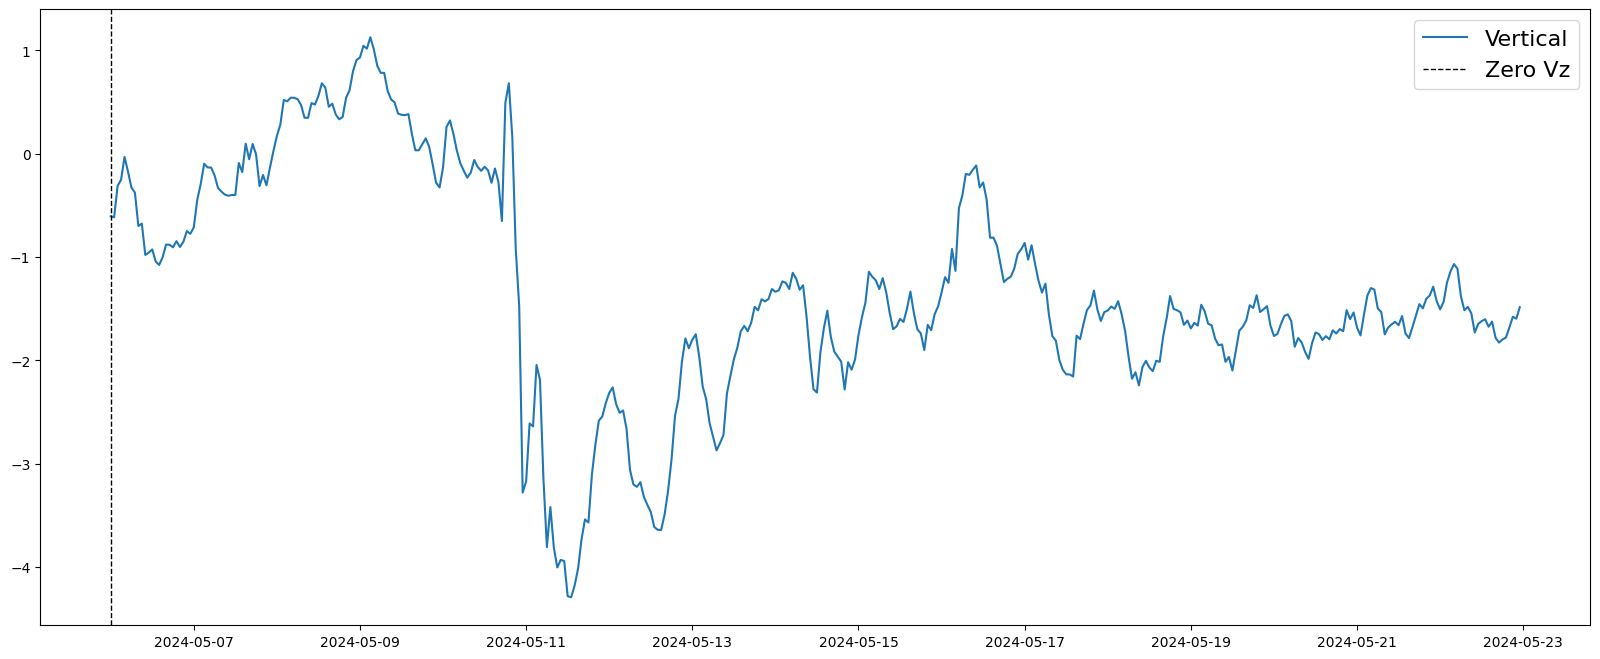

In [1865]:
fig = plt.figure(1, figsize = (20,8))
plt.plot(muons_df['UT'].to_numpy(), muons_df['V'].to_numpy(), label='Vertical')
plt.axvline(x=pd.to_datetime('2024-05-06 00:00:00'), color='black', linestyle='--', linewidth=1, label='Zero Vz') # Horizontal linebase

#plt.ylim(0, 250)
plt.legend(fontsize=16)
plt.show()

### CAMPO MAGNETICO LOCAL

In [1866]:
magne = "/home/peter/Desktop/ForbushProject/data/Nagoya_JAPAN_May_2024/Kakioka_Magnetometer_6_22_May_2024.txt"

#READ FILE AND REAPLACE EXISTING HEADER 	Hour 	X 	Y 	Z 	G
cols = ['Day', 'Hour', 'X', 'Y', 'Z', 'G']                                          
magne_df = pd.read_csv(magne, sep=r"\s+",skiprows=1,names=cols)#,skiprows=7

magne_df

,Day,Hour,X,Y,Z,G
0,2024-05-06,00:00:00,29798.4,-4128.2,35937.3,46866.58
1,2024-05-06,00:01:00,29798.4,-4131.9,35937.4,46866.98
2,2024-05-06,00:02:00,29799.5,-4134.8,35938.6,46868.96
3,2024-05-06,00:03:00,29802.1,-4136.5,35940.7,46872.37
4,2024-05-06,00:04:00,29803.6,-4133.5,35941.7,46873.83
...,...,...,...,...,...,...
24475,2024-05-22,23:55:00,29828.3,-4130.7,35939.9,46887.81
24476,2024-05-22,23:56:00,29828.2,-4131.3,35939.7,46887.64
24477,2024-05-22,23:57:00,29827.9,-4131.7,35939.8,46887.47
24478,2024-05-22,23:58:00,29827.8,-4132.2,35939.7,46887.47


In [1867]:
magne_df['UT'] = pd.date_range( start='2024-05-06 00:00:00', periods=len(magne_df), freq='1min')

### REMUESTREO A 1 HORA DE LOS DATOS PARA LA CORRELACIÓN

In [1868]:
nmdb_quiet_hourly = (
    nmdb_df_quiet
    .set_index('UT')
    [['IRK3', 'YKTK', 'TXBY']]
    .resample('1h')
    .mean()
)

nmdb_quiet_hourly

,IRK3,YKTK,TXBY
UT,,,
2024-05-06 00:00:00,-0.072398,-0.447360,0.450040
2024-05-06 01:00:00,-0.002459,-0.102605,0.421833
2024-05-06 02:00:00,0.425409,0.040350,0.133468
2024-05-06 03:00:00,0.433637,0.069773,0.267257
2024-05-06 04:00:00,0.396610,0.527930,0.642248
...,...,...,...
2024-05-22 19:00:00,-4.478609,-4.226330,-3.770520
2024-05-22 20:00:00,-4.556778,-3.906645,-3.829079
2024-05-22 21:00:00,-4.466267,-3.857586,-3.819794


In [1869]:
dst_hourly = (
    dst_df
    .set_index('UT')
    [['Dst']]
    .resample('1h')
    .mean()
)

dst_hourly

,Dst
UT,
2024-05-06 01:00:00,-33.0
2024-05-06 02:00:00,-43.0
2024-05-06 03:00:00,-35.0
2024-05-06 04:00:00,-34.0
2024-05-06 05:00:00,-33.0
...,...
2024-05-22 20:00:00,6.0
2024-05-22 21:00:00,8.0
2024-05-22 22:00:00,8.0


In [1870]:
omni_hourly = (
    omni_df
    .set_index('UT')
    [['IMF_Bz','V_sw']]
    .resample('1h')
    .mean()
)

omni_hourly

,IMF_Bz,V_sw
UT,,
2024-05-06 00:00:00,-5.660667,375.890909
2024-05-06 01:00:00,8.522000,375.114583
2024-05-06 02:00:00,8.529667,371.359615
2024-05-06 03:00:00,7.308000,369.350909
2024-05-06 04:00:00,5.408333,369.100000
...,...,...
2024-05-22 19:00:00,7.275789,377.091837
2024-05-22 20:00:00,7.394615,373.553333
2024-05-22 21:00:00,5.854500,368.920588


In [1871]:
muons_hourly = (
    muons_df
    .set_index('UT')
    [['V']]
    .resample('1h')
    .mean()
)

muons_hourly

,V
UT,
2024-05-06 00:00:00,-0.605373
2024-05-06 01:00:00,-0.614640
2024-05-06 02:00:00,-0.311230
2024-05-06 03:00:00,-0.251205
2024-05-06 04:00:00,-0.030018
...,...
2024-05-22 19:00:00,-1.779319
2024-05-22 20:00:00,-1.681501
2024-05-22 21:00:00,-1.577287


In [1872]:
magne_hourly = (
    magne_df
    .set_index('UT')
    [['G']]
    .resample('1h')
    .mean()
)

magne_hourly

,G
UT,
2024-05-06 00:00:00,46877.171000
2024-05-06 01:00:00,46881.311667
2024-05-06 02:00:00,46887.955333
2024-05-06 03:00:00,46889.626000
2024-05-06 04:00:00,46885.294167
...,...
2024-05-22 19:00:00,46918.833000
2024-05-22 20:00:00,46918.564167
2024-05-22 21:00:00,46909.404333


### CONCATENACIÓN DE DATAFRAMES

In [1873]:
all_data = pd.concat([
    nmdb_quiet_hourly,
    dst_hourly,
    omni_hourly,
    muons_hourly,
    magne_hourly
], axis=1)

all_data

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G
UT,,,,,,,,
2024-05-06 00:00:00,-0.072398,-0.447360,0.450040,NaN,-5.660667,375.890909,-0.605373,46877.171000
2024-05-06 01:00:00,-0.002459,-0.102605,0.421833,-33.0,8.522000,375.114583,-0.614640,46881.311667
2024-05-06 02:00:00,0.425409,0.040350,0.133468,-43.0,8.529667,371.359615,-0.311230,46887.955333
2024-05-06 03:00:00,0.433637,0.069773,0.267257,-35.0,7.308000,369.350909,-0.251205,46889.626000
2024-05-06 04:00:00,0.396610,0.527930,0.642248,-34.0,5.408333,369.100000,-0.030018,46885.294167
...,...,...,...,...,...,...,...,...
2024-05-22 20:00:00,-4.556778,-3.906645,-3.829079,6.0,7.394615,373.553333,-1.681501,46918.564167
2024-05-22 21:00:00,-4.466267,-3.857586,-3.819794,8.0,5.854500,368.920588,-1.577287,46909.404333
2024-05-22 22:00:00,-4.680201,-3.672133,-3.566530,8.0,3.577333,389.200000,-1.596305,46901.555833


In [1874]:
all_data_clean = all_data.dropna()

all_data_clean

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G
UT,,,,,,,,
2024-05-06 01:00:00,-0.002459,-0.102605,0.421833,-33.0,8.522000,375.114583,-0.614640,46881.311667
2024-05-06 02:00:00,0.425409,0.040350,0.133468,-43.0,8.529667,371.359615,-0.311230,46887.955333
2024-05-06 03:00:00,0.433637,0.069773,0.267257,-35.0,7.308000,369.350909,-0.251205,46889.626000
2024-05-06 04:00:00,0.396610,0.527930,0.642248,-34.0,5.408333,369.100000,-0.030018,46885.294167
2024-05-06 05:00:00,0.458038,0.315199,0.942430,-33.0,0.943167,378.078261,-0.171748,46886.936000
...,...,...,...,...,...,...,...,...
2024-05-22 19:00:00,-4.478609,-4.226330,-3.770520,5.0,7.275789,377.091837,-1.779319,46918.833000
2024-05-22 20:00:00,-4.556778,-3.906645,-3.829079,6.0,7.394615,373.553333,-1.681501,46918.564167
2024-05-22 21:00:00,-4.466267,-3.857586,-3.819794,8.0,5.854500,368.920588,-1.577287,46909.404333


In [1875]:
corr_matrix = all_data_clean.corr()

corr_matrix

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G
IRK3,1.000000,0.979496,0.960427,0.703001,0.196005,-0.592615,0.910189,0.507701
YKTK,0.979496,1.000000,0.983053,0.752411,0.259046,-0.593509,0.911761,0.564938
TXBY,0.960427,0.983053,1.000000,0.747360,0.274257,-0.558770,0.890188,0.568813
Dst,0.703001,0.752411,0.747360,1.000000,0.545233,-0.635128,0.669766,0.863359
IMF_Bz,0.196005,0.259046,0.274257,0.545233,1.000000,-0.273305,0.224487,0.626711
V_sw,-0.592615,-0.593509,-0.558770,-0.635128,-0.273305,1.000000,-0.478052,-0.509941
V,0.910189,0.911761,0.890188,0.669766,0.224487,-0.478052,1.000000,0.451386
G,0.507701,0.564938,0.568813,0.863359,0.626711,-0.509941,0.451386,1.000000


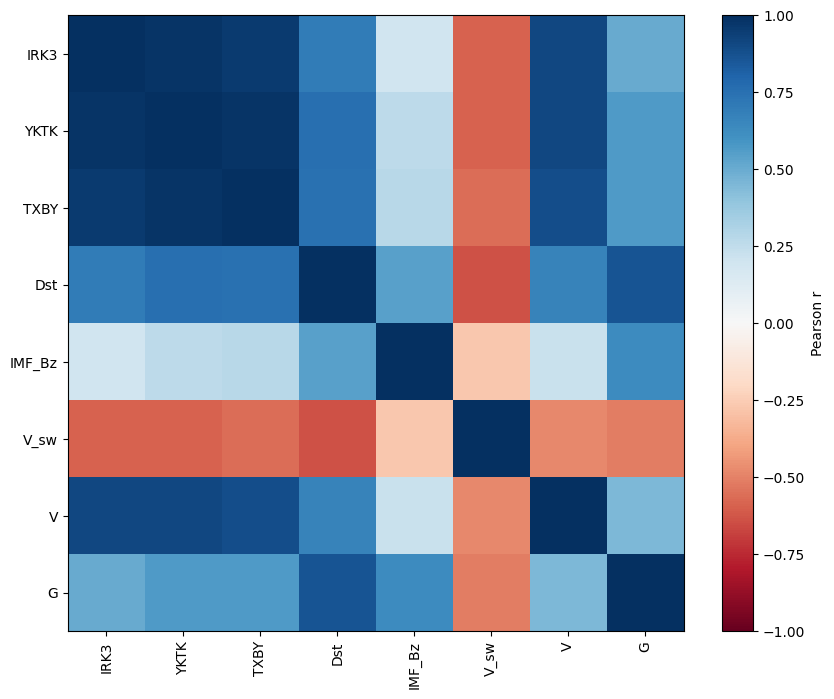

In [1876]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu') 

plt.colorbar(label='Pearson r')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

In [1877]:
all_data_clean = all_data_clean.reset_index()
#all_data_clean['UT'] = pd.to_datetime(all_data_clean['UT'])

In [1878]:
#kp_df = kp_df.reset_index()
#kp_df['UT'] = pd.to_datetime(kp_df['UT'])

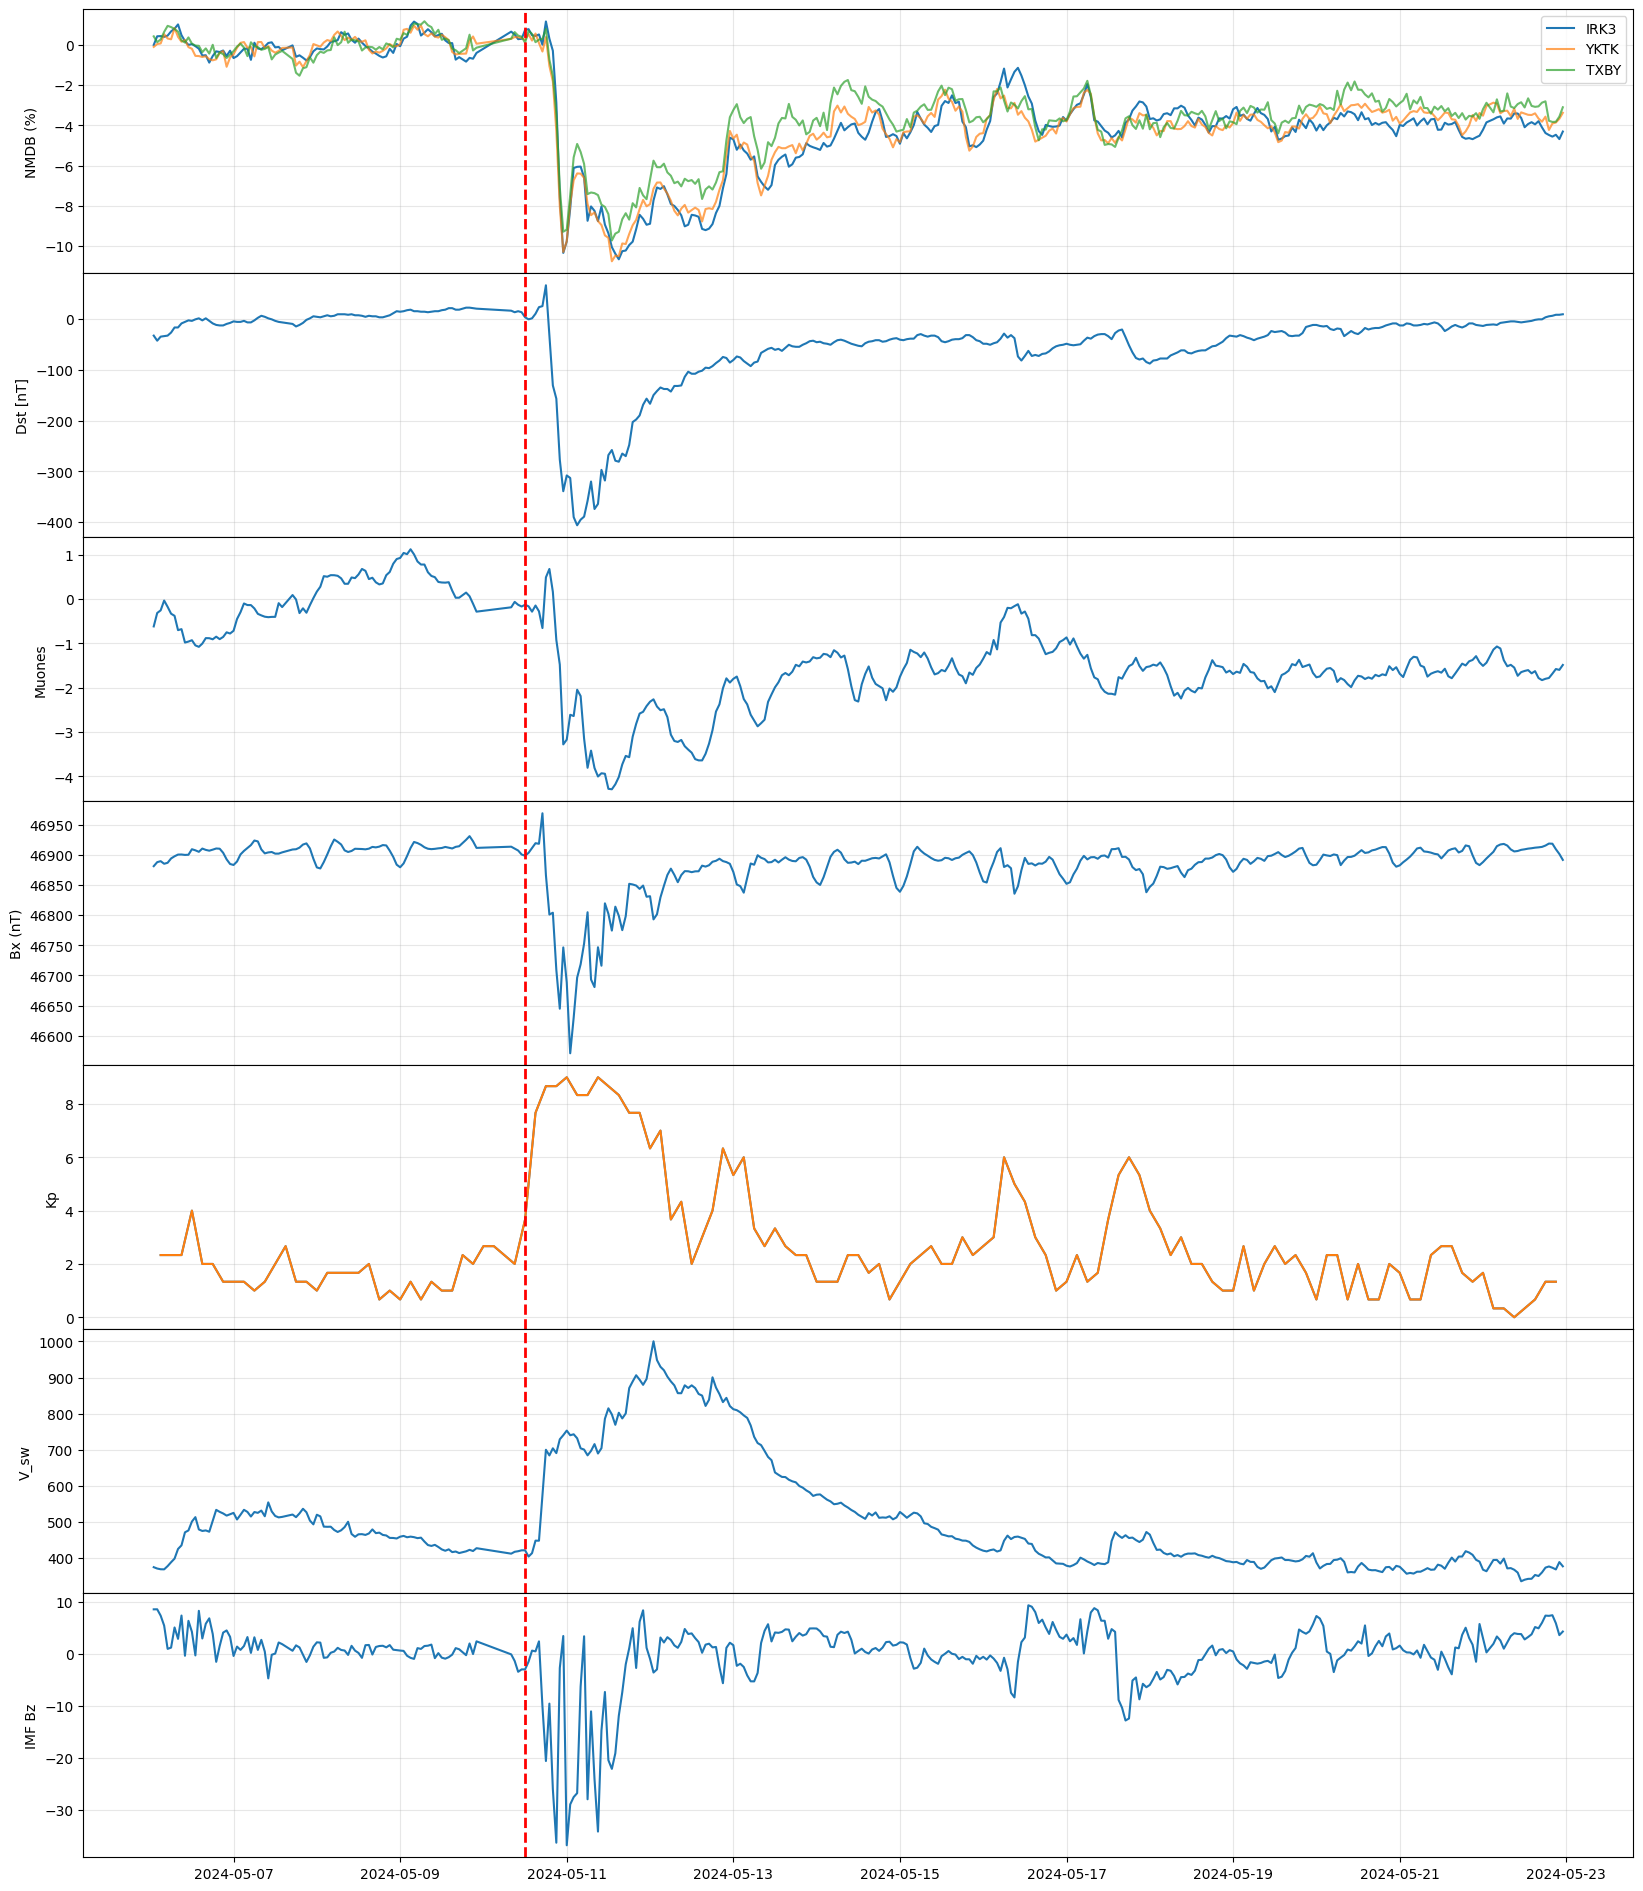

In [1879]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(
    7, 1,
    figsize=(20,24),
    sharex=True,
    gridspec_kw={'hspace': 0}
)

# NMDB

ax1.plot(
    all_data_clean['UT'],
    all_data_clean['IRK3'],
    linewidth=1.5,
    label='IRK3'
)

ax1.plot(
    all_data_clean['UT'],
    all_data_clean['YKTK'],
    linewidth=1.5,
    alpha=0.7,
    label='YKTK'
)

ax1.plot(
    all_data_clean['UT'],
    all_data_clean['TXBY'],
    linewidth=1.5,
    alpha=0.7,
    label='TXBY'
)

ax1.set_ylabel('NMDB (%)')
ax1.legend()

# DST

ax2.plot(
    all_data_clean['UT'],
    all_data_clean['Dst'],
    linewidth=1.5
)

ax2.set_ylabel('Dst [nT]')

# Muones Vertical

ax3.plot(
    all_data_clean['UT'],
    all_data_clean['V'],
    linewidth=1.5
)

ax3.set_ylabel('Muones')

# Campo Magnetico Horizontal

ax4.plot(
    all_data_clean['UT'],
    all_data_clean['G'],
    linewidth=1.5
)

ax4.set_ylabel('Bx (nT)')

# Indice Kp

ax5.plot(
    kp_df['UT'],
    kp_df['kp'],
    linewidth=1.5
)

ax5.set_ylabel('Kp')

# B_total

ax5.plot(
    kp_df['UT'],
    kp_df['kp'],
    linewidth=1.5
)

ax5.set_ylabel('Kp')

# V_sw

ax6.plot(
    all_data_clean['UT'],
    all_data_clean['V_sw'],
    linewidth=1.5
)

ax6.set_ylabel('V_sw')

# B_z

ax7.plot(
    all_data_clean['UT'],
    all_data_clean['IMF_Bz'],
    linewidth=1.5
)

ax7.set_ylabel('IMF Bz')


# =========================================================
# LINEA VERTICAL GLOBAL
# =========================================================

evento = pd.to_datetime('2024-05-10 12:00:00')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    
    ax.axvline(
        evento,
        color='red',
        linestyle='--',
        linewidth=2
    )

    ax.grid(alpha=0.3)

plt.savefig("Plots.png", dpi=300)
plt.show()

### DEFINICIÓN DE CORRELACIÓN CRUZADA

In [1880]:
# FUNCIÓN DE CORRELACIÓN CRUZADA

def cross_corr(x, y, max_lag=48):

    lags = np.arange(-max_lag, max_lag + 1)

    corrs = []

    for lag in lags:

        if lag < 0:

            corr = np.corrcoef(
                x[:lag],
                y[-lag:]
            )[0,1]

        elif lag > 0:

            corr = np.corrcoef(
                x[lag:],
                y[:-lag]
            )[0,1]

        else:

            corr = np.corrcoef(
                x,
                y
            )[0,1]

        corrs.append(corr)

    return lags, np.array(corrs)

In [1881]:
# Muones VS TODAS

target = 'V'

variables_cc = [
    'IRK3',
    'YKTK',
    'TXBY',
    'Dst',
    'G',
    'V_sw',
    'IMF_Bz'
]

crosscorr_results = {}

for var in variables_cc:

    lags, corrs = cross_corr(
        all_data_clean[target].values,
        all_data_clean[var].values,
        max_lag=24
    )

    crosscorr_results[var] = {
        'lags': lags,
        'corrs': corrs
    }

print("Correlaciones cruzadas calculadas")
crosscorr_results

Correlaciones cruzadas calculadas


{'IRK3': {'lags': array([-24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
         -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
           2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
          15,  16,  17,  18,  19,  20,  21,  22,  23,  24]),
  'corrs': array([0.54495033, 0.56056772, 0.57397765, 0.58553643, 0.59674335,
         0.60870651, 0.6227923 , 0.63783145, 0.65558164, 0.67108857,
         0.68632868, 0.70121278, 0.7164239 , 0.73394726, 0.75515041,
         0.77736711, 0.79813351, 0.81730983, 0.83114249, 0.84266456,
         0.85690698, 0.87432179, 0.89327952, 0.90739895, 0.91018852,
         0.89594629, 0.87078878, 0.84084337, 0.81353165, 0.79249493,
         0.78030492, 0.76771647, 0.75164718, 0.73577089, 0.72140563,
         0.70693183, 0.6950626 , 0.68416621, 0.67326193, 0.66088059,
         0.64837219, 0.63662013, 0.62328375, 0.60857507, 0.59009659,
         0.56936149, 0.54660159, 0.52548579, 0.50570751])},
 'YKTK': {'

In [1882]:
# RESUMEN RETARDOS

summary = []

for var in variables_cc:

    lags = crosscorr_results[var]['lags']
    corrs = crosscorr_results[var]['corrs']

    idx = np.nanargmax(np.abs(corrs))

    summary.append([
        var,
        lags[idx],
        corrs[idx]
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        'Variable',
        'Lag_optimo_horas',
        'Correlacion'
    ]
)

summary_df = summary_df.sort_values(
    by='Correlacion',
    key=np.abs,
    ascending=False
)

summary_df.reset_index(drop=True)

,Variable,Lag_optimo_horas,Correlacion
0,YKTK,0,0.911761
1,IRK3,0,0.910189
2,TXBY,0,0.890188
3,Dst,3,0.711761
4,G,10,0.617053
5,V_sw,4,-0.486667
6,IMF_Bz,12,0.363069


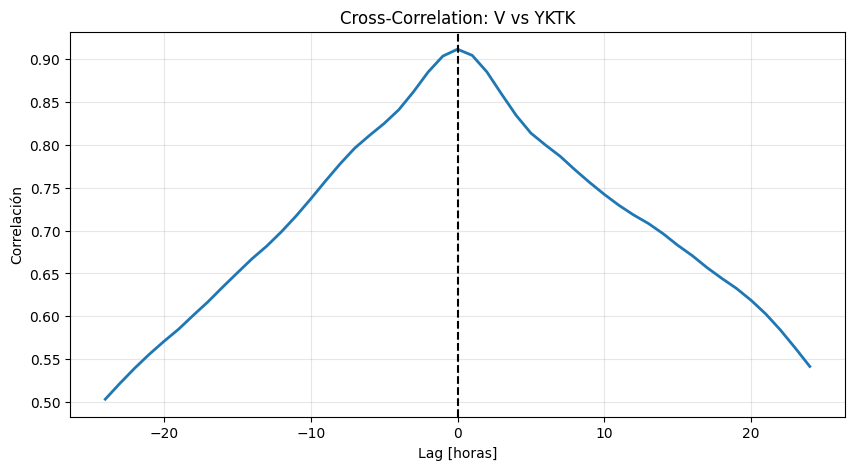

In [1883]:
# =========================================================
# V vs YKTK
# =========================================================

var = 'YKTK'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'YKTK', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

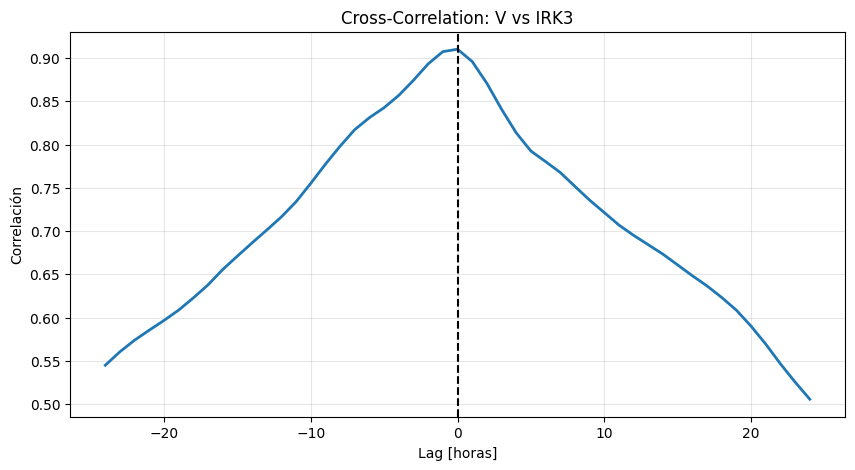

In [1884]:
# =========================================================
# V vs IRK3
# =========================================================

var = 'IRK3'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'IRK3', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

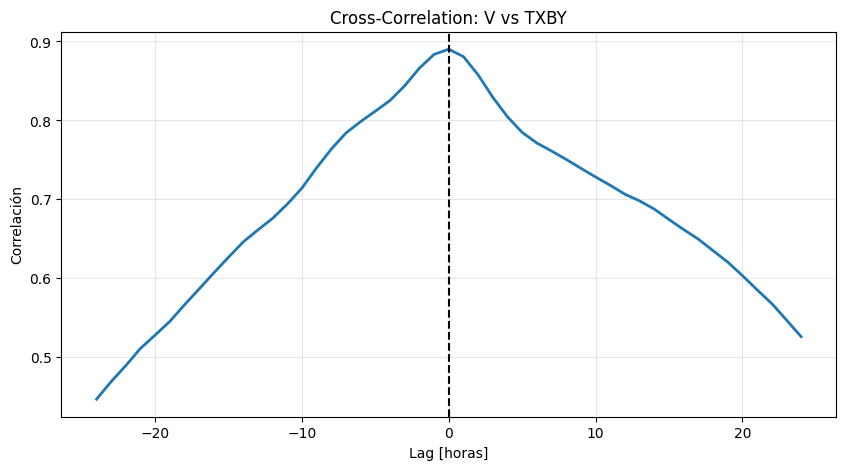

In [1885]:
# =========================================================
# V vs TXBY
# =========================================================

var = 'TXBY'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'TXBY', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

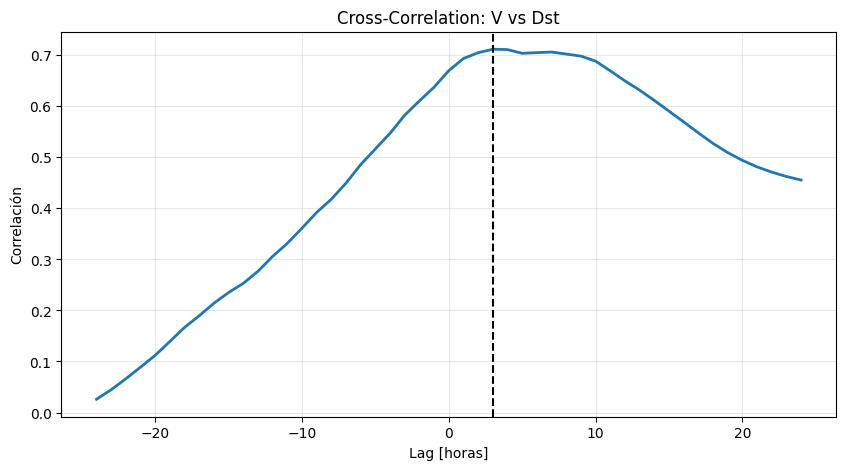

In [1886]:
# =========================================================
# V vs Dst
# =========================================================

var = 'Dst'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'Dst', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

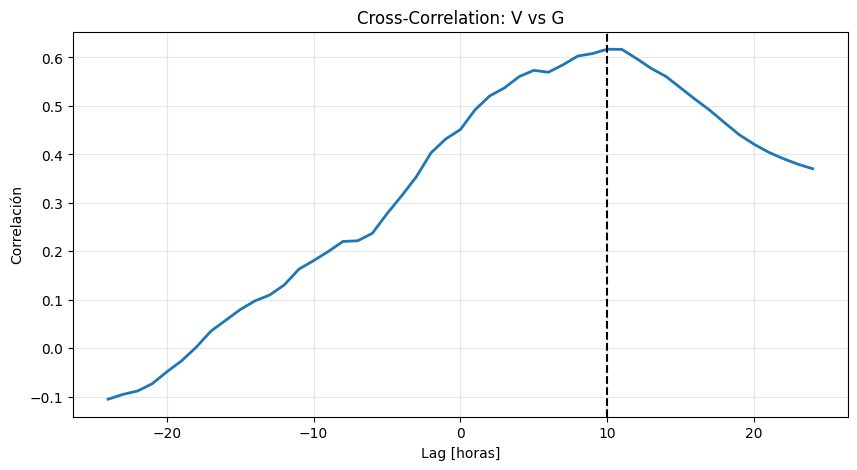

In [1887]:
# =========================================================
# V vs G
# =========================================================

var = 'G'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'G', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

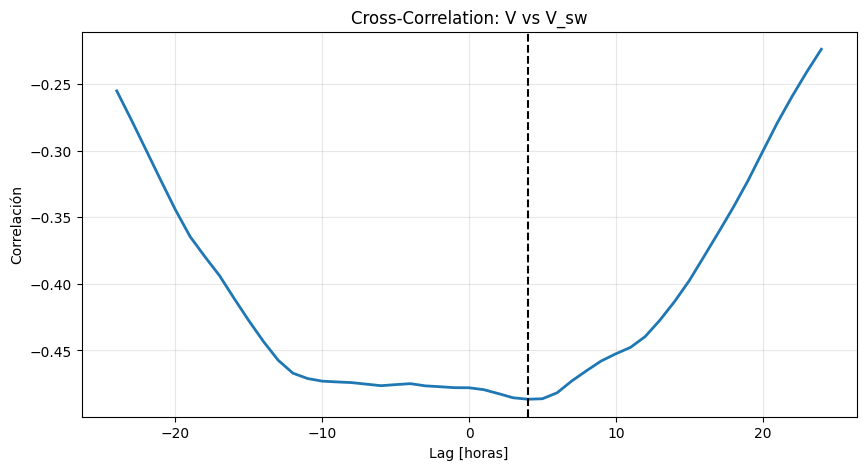

In [1888]:
# =========================================================
# V vs V_sw
# =========================================================

var = 'V_sw'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'V_sw', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

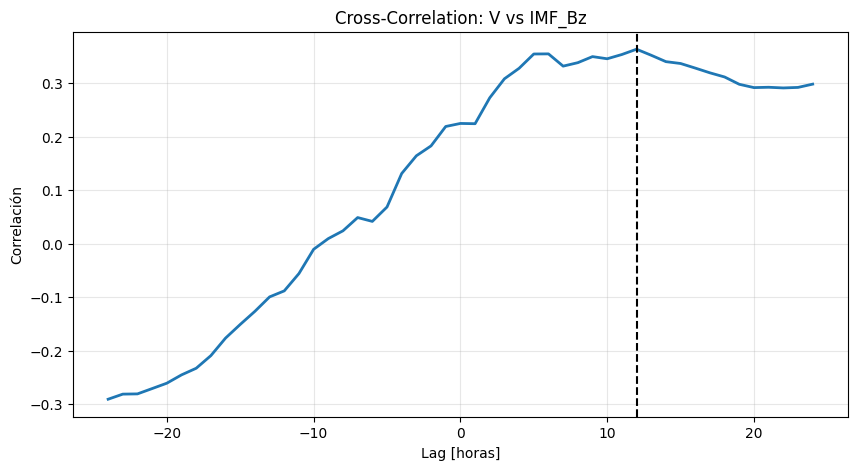

In [1889]:
# =========================================================
# V vs IMF_Bz
# =========================================================

var = 'IMF_Bz'

plt.figure(figsize=(10,5))

plt.plot(
    crosscorr_results[var]['lags'],
    crosscorr_results[var]['corrs'],
    linewidth=2
)

plt.axvline(
    summary_df.loc[summary_df['Variable'] == 'IMF_Bz', 'Lag_optimo_horas'].iloc[0],
    color='black',
    linestyle='--'
)

plt.xlabel('Lag [horas]')
plt.ylabel('Correlación')
plt.title(f'Cross-Correlation: V vs {var}')
plt.grid(alpha=0.3)

plt.show()

### ESTUDIO DEL FORBUSH DECREASE

In [1890]:
fd_data = all_data.loc[all_data.index > '2024-05-10 12:00:00', ['V']].copy()
fd_data = fd_data.dropna()

fd_data

,V
UT,
2024-05-10 13:00:00,-0.160164
2024-05-10 14:00:00,-0.280941
2024-05-10 15:00:00,-0.142599
2024-05-10 16:00:00,-0.273092
2024-05-10 17:00:00,-0.651325
...,...
2024-05-22 19:00:00,-1.779319
2024-05-22 20:00:00,-1.681501
2024-05-22 21:00:00,-1.577287


In [1891]:
# CALCULO DE LA PROFUNDIDAD DEL EVENTO

idx_min = fd_data['V'].idxmin()

t_min = idx_min

fd_min = fd_data.loc[idx_min, 'V']

print("Tiempo mínimo:", t_min)
print("Profundidad FD (%):", fd_min)

Tiempo mínimo: 2024-05-11 13:00:00
Profundidad FD (%): -4.293350556505831


In [1892]:
# LIMITE PARA EL CALCULO DEL INICIO DEL EVENTO
idx_max = fd_data['V'].idxmax()

t_max = idx_max

fd_max = fd_data.loc[idx_max, 'V']

threshold_start = 0.1 * fd_min

In [1893]:
# CALCULO DEL INICIO DEL EVENTO

before_max = fd_data.loc[:t_max]

start_candidates = before_max[
    before_max['V'] < threshold_start
]

t_start = start_candidates.index[-1]

print("Inicio FD:", t_start)

Inicio FD: 2024-05-10 17:00:00


In [1894]:
# CALCULO DE FIN DE EVENTO
threshold_end = 0.1 * fd_min

after_min = fd_data.loc[t_min:]

end_candidates = after_min[
    after_min['V'] > threshold_end
]

t_end = end_candidates.index[0]

print("Fin FD:", t_end)

Fin FD: 2024-05-16 06:00:00


In [1895]:
duration_total = (t_end - t_start).total_seconds()/3600

duration_fall = (t_min - t_start).total_seconds()/3600

duration_recovery = (t_end - t_min).total_seconds()/3600

In [1896]:
# CARACTERISTICAS DEL FORBUSH DECREASE

fd_summary = pd.DataFrame({
    'Parametro':[
        'Inicio',
        'Minimo',
        'Fin',
        'Profundidad (%)',
        'Duracion total (h)',
        'Tiempo descenso (h)',
        'Tiempo recuperacion (h)'
    ],
    'Valor':[
        t_start,
        t_min,
        t_end,
        round(fd_min,2),
        round(duration_total,2),
        round(duration_fall,2),
        round(duration_recovery,2)
    ]
})

fd_summary

,Parametro,Valor
0,Inicio,2024-05-10 17:00:00
1,Minimo,2024-05-11 13:00:00
2,Fin,2024-05-16 06:00:00
3,Profundidad (%),-4.29
4,Duracion total (h),133.0
5,Tiempo descenso (h),20.0
6,Tiempo recuperacion (h),113.0


### LOWESS

In [1897]:
N = len(all_data_clean)
frac = duration_total / N
print(frac)

0.33756345177664976


In [1898]:
from statsmodels.nonparametric.smoothers_lowess import lowess

In [1899]:
all_data_clean['UT'] = pd.to_datetime(
    all_data_clean['UT']
)

all_data_clean = all_data_clean.set_index('UT')

In [1900]:
# LOWESS BASELINE

x = np.arange(len(all_data_clean))

y = all_data_clean['V'].values

lowess_fit = lowess(
    y,
    x,
    frac=0.1,      # ajustar luego
    return_sorted=False
)

all_data_clean['baseline_lowess'] = lowess_fit

In [1901]:
all_data_clean['residual'] = (
    all_data_clean['V']
    - all_data_clean['baseline_lowess']
)

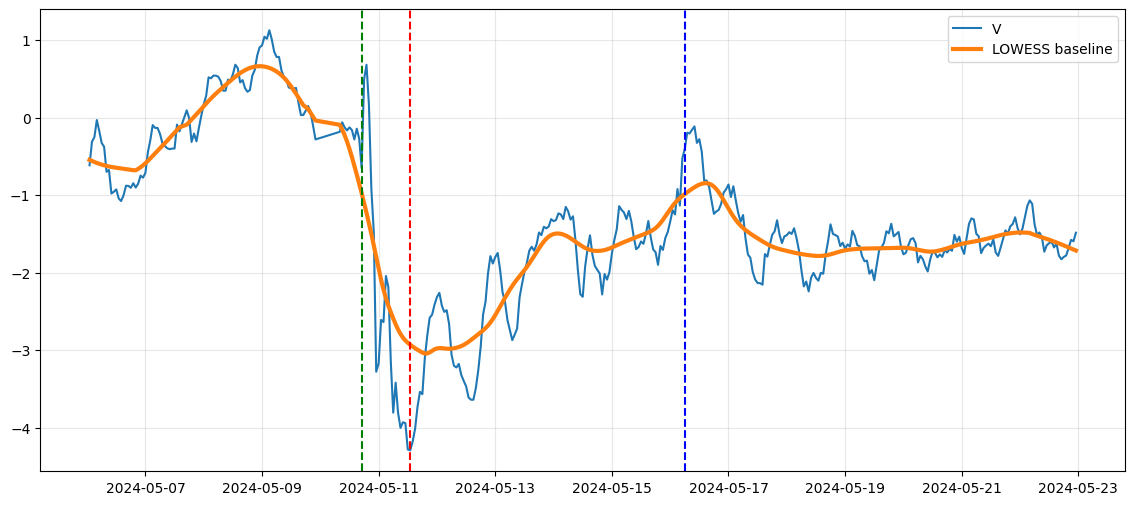

In [1902]:
plt.figure(figsize=(14,6))

plt.plot(
    all_data_clean.index,
    all_data_clean['V'],
    label='V'
)

plt.plot(
    all_data_clean.index,
    all_data_clean['baseline_lowess'],
    linewidth=3,
    label='LOWESS baseline'
)

plt.axvline(pd.to_datetime(t_start),color='green',linestyle='--')
plt.axvline(pd.to_datetime(t_min),color='red',linestyle='--')
plt.axvline(pd.to_datetime(t_end),color='blue',linestyle='--')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

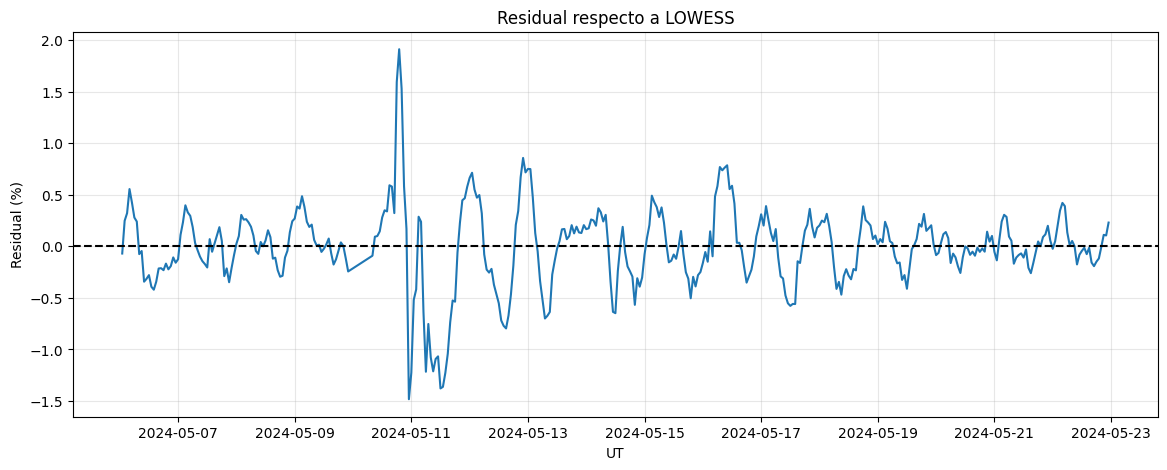

In [1903]:
# PLOTEO DE RESIDUO DE LOWESS

plt.figure(figsize=(14,5))

plt.plot(
    all_data_clean.index,
    all_data_clean['residual']
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.xlabel('UT')
plt.ylabel('Residual (%)')

plt.title('Residual respecto a LOWESS')

plt.grid(alpha=0.3)

plt.show()

In [1904]:
idx_min = all_data_clean['residual'].idxmin()
fd_min = all_data_clean.loc[idx_min, 'residual']
print(fd_min)

-1.4820217406544605


### CONCATENAR RESIDUOS CON TODOS LOS DATOS

In [1905]:
corr_matrix = all_data_clean.corr()

corr_matrix

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G,baseline_lowess,residual
IRK3,1.000000,0.979496,0.960427,0.703001,0.196005,-0.592615,0.910189,0.507701,0.897168,0.377835
YKTK,0.979496,1.000000,0.983053,0.752411,0.259046,-0.593509,0.911761,0.564938,0.898599,0.378768
TXBY,0.960427,0.983053,1.000000,0.747360,0.274257,-0.558770,0.890188,0.568813,0.874765,0.375899
Dst,0.703001,0.752411,0.747360,1.000000,0.545233,-0.635128,0.669766,0.863359,0.621633,0.369316
IMF_Bz,0.196005,0.259046,0.274257,0.545233,1.000000,-0.273305,0.224487,0.626711,0.196240,0.152469
V_sw,-0.592615,-0.593509,-0.558770,-0.635128,-0.273305,1.000000,-0.478052,-0.509941,-0.512271,-0.101230
V,0.910189,0.911761,0.890188,0.669766,0.224487,-0.478052,1.000000,0.451386,0.934352,0.536688
G,0.507701,0.564938,0.568813,0.863359,0.626711,-0.509941,0.451386,1.000000,0.439299,0.200709
baseline_lowess,0.897168,0.898599,0.874765,0.621633,0.196240,-0.512271,0.934352,0.439299,1.000000,0.200773
residual,0.377835,0.378768,0.375899,0.369316,0.152469,-0.101230,0.536688,0.200709,0.200773,1.000000


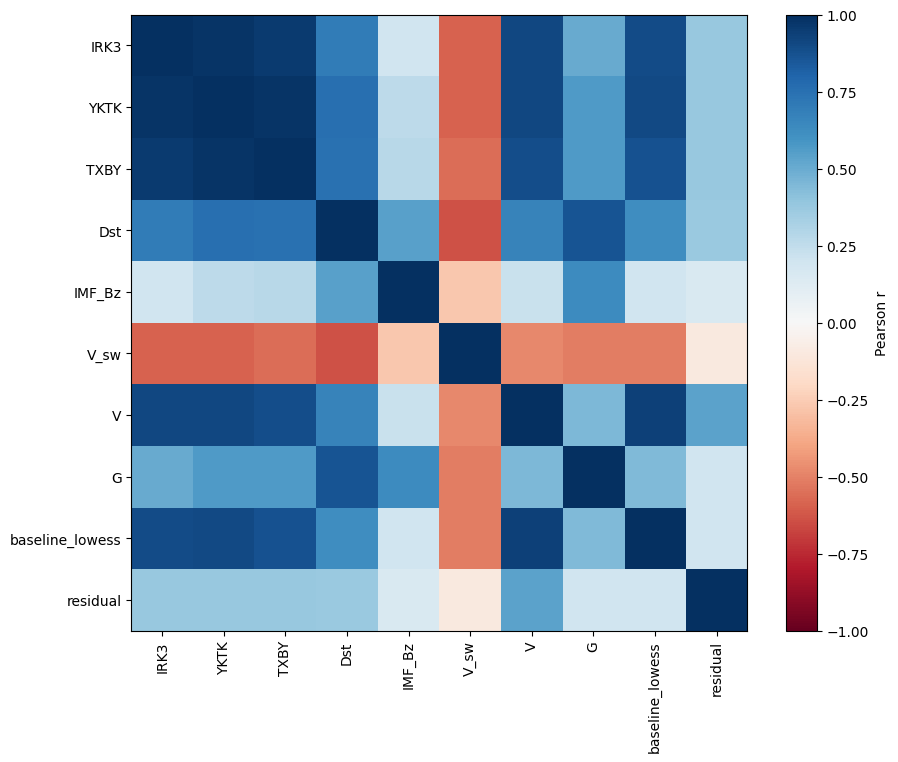

In [1906]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu') 

plt.colorbar(label='Pearson r')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

### FFT DE LA SEÑAL

In [1907]:
signal = all_data_clean['residual'].values

In [1908]:
from scipy.fft import fft, fftfreq
import numpy as np

In [1909]:
N = len(signal)

dt = 1.0   # horas

fft_values = fft(signal)

freqs = fftfreq(
    N,
    d=dt
)

In [1910]:
mask = freqs > 0

freqs_pos = freqs[mask]

power = np.abs(
    fft_values[mask]
)**2

In [1911]:
periods = 1 / freqs_pos

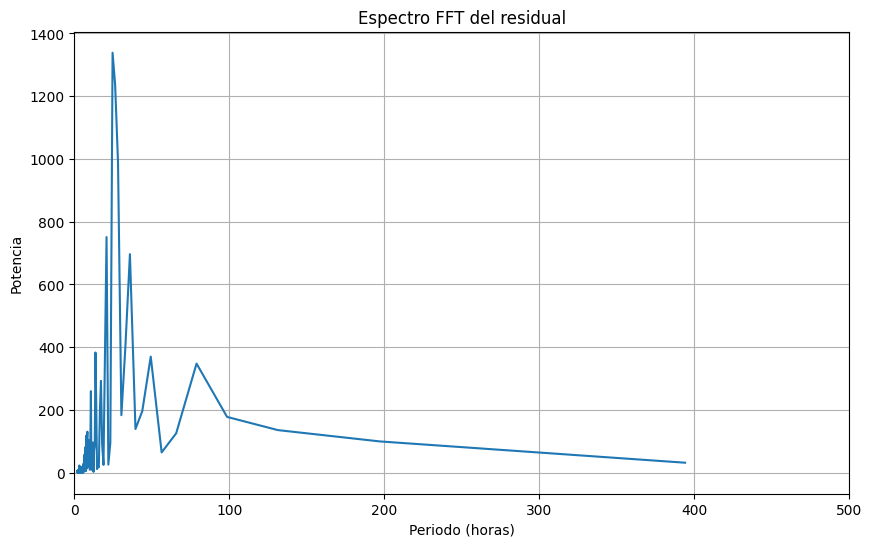

In [1912]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    periods,
    power
)

plt.xlim(0,500)

plt.xlabel('Periodo (horas)')
plt.ylabel('Potencia')

plt.title('Espectro FFT del residual')

plt.grid(True)

plt.show()

In [1913]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(
    power,
    prominence=np.max(power)*0.05
)

peak_periods = periods[peaks]
peak_powers = power[peaks]

for p, pw in sorted(
    zip(peak_periods, peak_powers),
    key=lambda x: x[1],
    reverse=True
):
    print(f"Periodo = {p:.2f} h | Potencia = {pw:.2f}")

Periodo = 24.63 h | Potencia = 1338.52
Periodo = 20.74 h | Potencia = 750.99
Periodo = 35.82 h | Potencia = 696.54
Periodo = 13.59 h | Potencia = 383.09
Periodo = 49.25 h | Potencia = 369.97
Periodo = 78.80 h | Potencia = 347.79
Periodo = 17.13 h | Potencia = 292.66
Periodo = 10.65 h | Potencia = 260.07
Periodo = 8.38 h | Potencia = 130.86
Periodo = 7.58 h | Potencia = 117.88
Periodo = 9.38 h | Potencia = 104.41
Periodo = 11.94 h | Potencia = 96.47
Periodo = 7.04 h | Potencia = 81.45


In [1914]:
### LOMB SCARGLE

In [1915]:
times = all_data_clean.index

In [1916]:
t_hours = (
    (times - times[0])
    .total_seconds()
    / 3600
)

In [1917]:
y = all_data_clean['residual'].values

In [1918]:
from astropy.timeseries import LombScargle
import numpy as np

In [1919]:
periods = np.linspace(
    2,
    500,
    5000
)

In [1920]:
frequencies = 1 / periods

In [1921]:
ls = LombScargle(
    t_hours,
    y
)

power = ls.power(
    frequencies
)

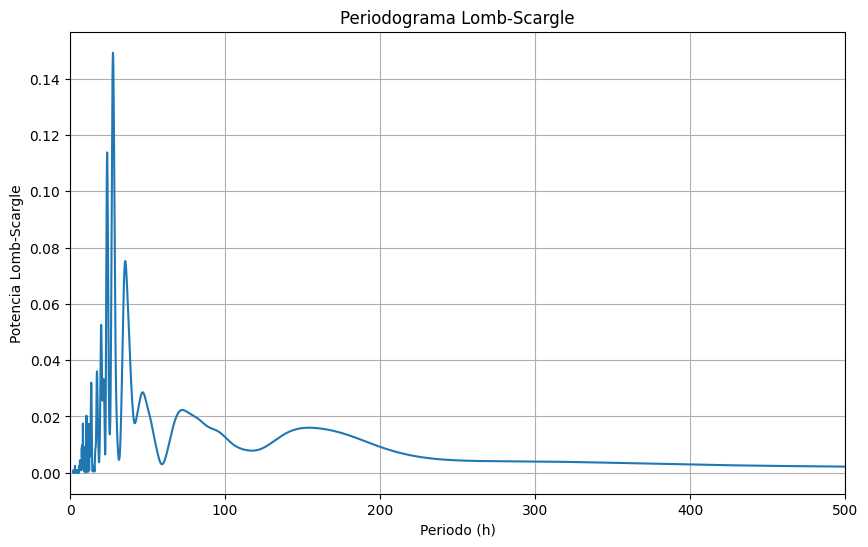

In [1922]:
plt.figure(figsize=(10,6))

plt.plot(
    periods,
    power
)

plt.xlim(0,500)

plt.xlabel('Periodo (h)')
plt.ylabel('Potencia Lomb-Scargle')

plt.title(
    'Periodograma Lomb-Scargle'
)

plt.grid(True)

plt.show()

In [1923]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(
    power,
    prominence=np.max(power)*0.05
)

for p, pw in sorted(
    zip(periods[peaks], power[peaks]),
    key=lambda x: x[1],
    reverse=True
):
    print(
        f'Periodo = {p:.2f} h | Potencia = {pw:.3f}'
    )

Periodo = 27.70 h | Potencia = 0.149
Periodo = 23.92 h | Potencia = 0.114
Periodo = 35.67 h | Potencia = 0.075
Periodo = 20.13 h | Potencia = 0.053
Periodo = 17.44 h | Potencia = 0.036
Periodo = 21.72 h | Potencia = 0.033
Periodo = 13.66 h | Potencia = 0.032
Periodo = 46.83 h | Potencia = 0.029
Periodo = 72.43 h | Potencia = 0.022
Periodo = 10.57 h | Potencia = 0.020
Periodo = 8.28 h | Potencia = 0.017
Periodo = 12.06 h | Potencia = 0.017
Periodo = 154.22 h | Potencia = 0.016
Periodo = 9.17 h | Potencia = 0.009


### DESPLAZAMOS LOS DATOS A SUS RETRASOS ÓPTIMOS

In [1951]:
muons_df['UT'] = pd.to_datetime(muons_df['UT'])

muons_df = muons_df.set_index('UT')

In [1952]:
model_df = all_data_clean.copy()

model_df['Dst_lag'] = model_df['Dst'].shift(3)

model_df['Vsw_lag'] = model_df['V_sw'].shift(4)

model_df['IMF_Bz_lag'] = model_df['IMF_Bz'].shift(12)

model_df['G_lag'] = model_df['G'].shift(10)

model_df['Pres'] = muons_df['Pres'].reindex(
    model_df.index
)

In [1953]:
model_df

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G,baseline_lowess,residual,Dst_lag,Vsw_lag,IMF_Bz_lag,G_lag,Pres
UT,,,,,,,,,,,,,,,
2024-05-06 01:00:00,-0.002459,-0.102605,0.421833,-33.0,8.522000,375.114583,-0.614640,46881.311667,-0.544666,-0.069974,NaN,NaN,NaN,NaN,1009.719
2024-05-06 02:00:00,0.425409,0.040350,0.133468,-43.0,8.529667,371.359615,-0.311230,46887.955333,-0.559039,0.247809,NaN,NaN,NaN,NaN,1010.010
2024-05-06 03:00:00,0.433637,0.069773,0.267257,-35.0,7.308000,369.350909,-0.251205,46889.626000,-0.572434,0.321229,NaN,NaN,NaN,NaN,1010.258
2024-05-06 04:00:00,0.396610,0.527930,0.642248,-34.0,5.408333,369.100000,-0.030018,46885.294167,-0.584777,0.554759,-33.0,NaN,NaN,NaN,1009.536
2024-05-06 05:00:00,0.458038,0.315199,0.942430,-33.0,0.943167,378.078261,-0.171748,46886.936000,-0.596019,0.424271,-43.0,375.114583,NaN,NaN,1008.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-22 19:00:00,-4.478609,-4.226330,-3.770520,5.0,7.275789,377.091837,-1.779319,46918.833000,-1.661702,-0.117617,-1.0,353.548780,2.208596,46905.759667,1005.966
2024-05-22 20:00:00,-4.556778,-3.906645,-3.829079,6.0,7.394615,373.553333,-1.681501,46918.564167,-1.674989,-0.006513,-1.0,350.674194,3.402407,46906.501333,1006.072
2024-05-22 21:00:00,-4.466267,-3.857586,-3.819794,8.0,5.854500,368.920588,-1.577287,46909.404333,-1.688354,0.111067,3.0,360.627586,3.945593,46908.410500,1006.048


In [1955]:
#Definición de datos a condiciones normales

quiet_end = pd.Timestamp('2024-05-10 12:00:00')

quiet = model_df.loc[
    model_df.index < quiet_end
]

In [1956]:
quiet

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G,baseline_lowess,residual,Dst_lag,Vsw_lag,IMF_Bz_lag,G_lag,Pres
UT,,,,,,,,,,,,,,,
2024-05-06 01:00:00,-0.002459,-0.102605,0.421833,-33.0,8.522000,375.114583,-0.614640,46881.311667,-0.544666,-0.069974,NaN,NaN,NaN,NaN,1009.719
2024-05-06 02:00:00,0.425409,0.040350,0.133468,-43.0,8.529667,371.359615,-0.311230,46887.955333,-0.559039,0.247809,NaN,NaN,NaN,NaN,1010.010
2024-05-06 03:00:00,0.433637,0.069773,0.267257,-35.0,7.308000,369.350909,-0.251205,46889.626000,-0.572434,0.321229,NaN,NaN,NaN,NaN,1010.258
2024-05-06 04:00:00,0.396610,0.527930,0.642248,-34.0,5.408333,369.100000,-0.030018,46885.294167,-0.584777,0.554759,-33.0,NaN,NaN,NaN,1009.536
2024-05-06 05:00:00,0.458038,0.315199,0.942430,-33.0,0.943167,378.078261,-0.171748,46886.936000,-0.596019,0.424271,-43.0,375.114583,NaN,NaN,1008.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-09 22:00:00,-0.401527,0.055602,-0.140934,20.0,2.387059,427.671429,-0.280975,46911.656833,-0.037351,-0.243624,22.0,414.194444,1.760800,46910.908167,1012.708
2024-05-10 08:00:00,0.655799,0.296626,0.306965,16.0,-0.111034,412.541860,-0.182777,46913.635833,-0.091788,-0.090989,22.0,418.958974,-0.837069,46911.473500,1011.796
2024-05-10 09:00:00,0.511805,0.386153,0.632857,13.0,-1.379492,417.702381,-0.060238,46910.502500,-0.153473,0.093235,21.0,423.107692,0.123636,46913.235167,1012.122


In [1957]:
quiet = quiet.dropna()
quiet

,IRK3,YKTK,TXBY,Dst,IMF_Bz,V_sw,V,G,baseline_lowess,residual,Dst_lag,Vsw_lag,IMF_Bz_lag,G_lag,Pres
UT,,,,,,,,,,,,,,,
2024-05-06 13:00:00,-0.064170,-0.547720,-0.035352,-1.0,-0.309667,513.608511,-1.042871,46907.613167,-0.651160,-0.391711,-6.0,435.551429,8.522000,46889.626000,1006.356
2024-05-06 14:00:00,-0.191708,-0.557538,-0.049385,1.0,8.237544,479.511628,-1.075892,46905.126000,-0.655372,-0.420520,-3.0,471.617308,8.529667,46885.294167,1005.678
2024-05-06 15:00:00,-0.529065,-0.603341,-0.363636,-3.0,2.929661,475.366667,-1.002486,46910.529500,-0.659548,-0.342937,-4.0,476.809756,7.308000,46886.936000,1004.943
2024-05-06 16:00:00,-0.516722,-0.564051,-0.176175,1.0,5.764667,476.833333,-0.878840,46908.321833,-0.663923,-0.214917,-1.0,501.364000,5.408333,46894.124333,1003.971
2024-05-06 17:00:00,-0.882878,-0.713519,-0.436298,-4.0,6.798529,473.211111,-0.880810,46907.008833,-0.668714,-0.212096,1.0,513.608511,0.943167,46897.724667,1003.033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-09 22:00:00,-0.401527,0.055602,-0.140934,20.0,2.387059,427.671429,-0.280975,46911.656833,-0.037351,-0.243624,22.0,414.194444,1.760800,46910.908167,1012.708
2024-05-10 08:00:00,0.655799,0.296626,0.306965,16.0,-0.111034,412.541860,-0.182777,46913.635833,-0.091788,-0.090989,22.0,418.958974,-0.837069,46911.473500,1011.796
2024-05-10 09:00:00,0.511805,0.386153,0.632857,13.0,-1.379492,417.702381,-0.060238,46910.502500,-0.153473,0.093235,21.0,423.107692,0.123636,46913.235167,1012.122


In [1959]:
# Calculo de promedios de tiempos quietos

G0 = quiet['G'].mean()

Dst0 = quiet['Dst'].mean()

Vsw0 = quiet['V_sw'].mean()

Bz0 = quiet['IMF_Bz'].mean()

P0 = quiet['Pres'].mean()

In [1960]:
model_df['G_norm'] = ( model_df['G_lag'] - G0) / G0
model_df['Dst_norm'] = ( model_df['Dst_lag'] - Dst0)
model_df['Vsw_norm'] = ( model_df['Vsw_lag'] - Vsw0) / Vsw0
model_df['Bz_norm'] = ( model_df['IMF_Bz_lag'] - Bz0)

### CONSTRUCCIÓN M(t) Y MODELADO (AÚN EN PRUEBA)

In [1961]:
beta = -0.12/100 # Dato de la web

In [1964]:
# Calculo de termino barometrico

model_df['Barometric'] = np.exp(
    -beta*
    (
        model_df['Pres']-P0
    )
)

In [1963]:
# Calculo de termino magnetico

model_df['G_rel'] = (
    model_df['G_lag'] - G0
)/G0

In [1965]:
model_df['Dst_scaled'] = (
    model_df['Dst_lag']
    - model_df['Dst_lag'].mean()
)/model_df['Dst_lag'].std()

model_df['Vsw_scaled'] = (
    model_df['Vsw_lag']
    - model_df['Vsw_lag'].mean()
)/model_df['Vsw_lag'].std()

model_df['Bz_scaled'] = (
    model_df['IMF_Bz_lag']
    - model_df['IMF_Bz_lag'].mean()
)/model_df['IMF_Bz_lag'].std()

In [1966]:
fit_df = model_df[
    [
        'V',
        'Barometric',
        'G_rel',
        'Dst_scaled',
        'Vsw_scaled',
        'Bz_scaled'
    ]
].dropna()

In [1967]:
def muon_model(
    X,
    R0,
    gamma,
    a,
    b,
    c
):

    Barometric, G_rel, Dst, Vsw, Bz = X

    M = (
        1
        + a*Dst
        + b*Vsw
        + c*Bz
    )

    return (
        R0
        * Barometric
        * (1 + gamma*G_rel)
        * M
    )

In [1968]:
X = np.vstack([
    fit_df['Barometric'],
    fit_df['G_rel'],
    fit_df['Dst_scaled'],
    fit_df['Vsw_scaled'],
    fit_df['Bz_scaled']
])

y = fit_df['V'].values

In [1969]:
from scipy.optimize import curve_fit

In [1970]:
popt, pcov = curve_fit(
    muon_model,
    X,
    y,
    p0=[
        np.mean(y),
        0,
        0,
        0,
        0
    ]
)

In [1971]:
R0_fit, gamma_fit, a_fit, b_fit, c_fit = popt

In [1972]:
print('R0    =', R0_fit)
print('gamma =', gamma_fit)
print('a     =', a_fit)
print('b     =', b_fit)
print('c     =', c_fit)

R0    = -1.378635578606593
gamma = 12.071819226585667
a     = -0.5991350201870956
b     = 0.026678216453675373
c     = 0.07508084618904991


In [1973]:
fit_df['V_pred'] = muon_model(
    X,
    *popt
)

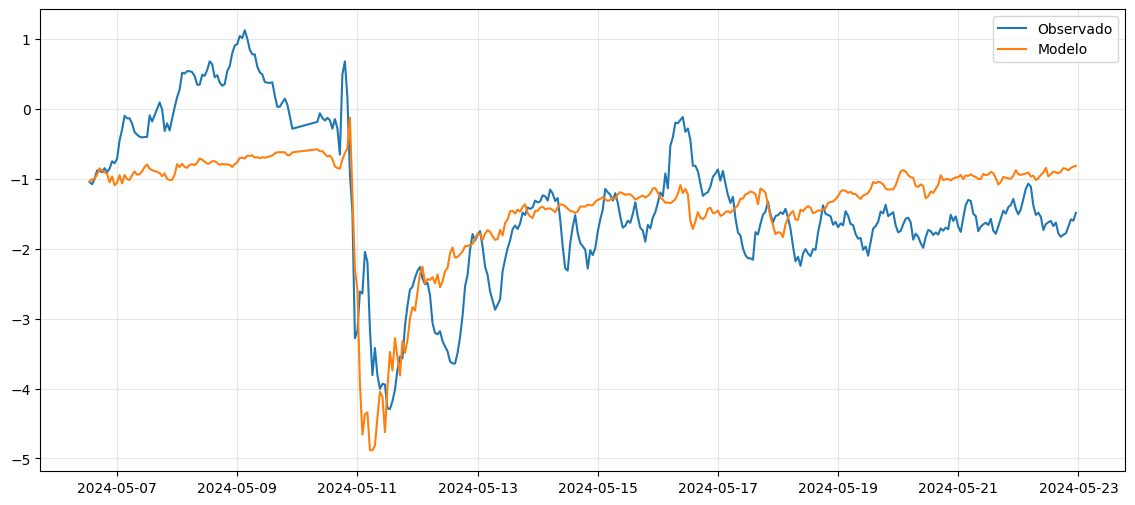

In [1974]:
plt.figure(figsize=(14,6))

plt.plot(
    fit_df.index,
    fit_df['V'],
    label='Observado'
)

plt.plot(
    fit_df.index,
    fit_df['V_pred'],
    label='Modelo'
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()